# NDT7 EDA — Vietnam Broadband & Mobile/Cellular (Combined)

Full exploratory analysis of Vietnam NDT7 (M-Lab) data, mirroring the structure of
`notebooks/ookla/vietnam_eda.ipynb` (Fixed Broadband + Mobile/Cellular) and
`notebooks/ndt7/cambodia_eda.ipynb`'s combined-format layout, so results are directly
comparable section-by-section across both countries and both data sources.

**Rebuilt from the original single-part (Broadband-only) `vietnam_eda.ipynb`** now that
`vietnam_ndt7_prep.ipynb` produces a Mobile export too (the raw file has 1.27M
cellular-classified rows the original prep never touched).

**Input:** `data/exports/ndt7_vietnam_province_quarterly.csv` (Broadband) and
`data/exports/ndt7_mobile_vietnam_province_quarterly.csv` (Mobile) — both produced by
`vietnam_ndt7_prep.ipynb` (tile-binned at Ookla's zoom-16 resolution, `is_reliable` computed
with `total_tests>=100` only (NDT7 drops the `n_tiles>=5` bar that Ookla keeps),
merged with `data/reference/vietnam_reference.csv`). This notebook does no raw-data
processing — it picks up where the prep notebook leaves off.

**Known result, stated up front (Broadband, unchanged from the original notebook):** 28.6%
of province-quarters overall are reliable, decaying sharply from ~48% in 2023 Q1 to ~11% by
2025 Q4 (NDT7 volume concentrated early in the study period) — see Section 1 below for the
exact per-quarter breakdown. **Mobile is far thinner: only 4 of 396 province-quarters (1.0%)
are reliable** — cellular is a much smaller slice of Vietnam's raw NDT7 volume (1.27M of
24.7M rows) than broadband is. Both sections below run with guard clauses so low/zero
reliable-row cases report explicitly instead of rendering blank or crashing (matching
Cambodia's approach, where Broadband and Mobile are both 0% reliable for a related but
more severe reason — see `cambodia_eda.ipynb`'s intro).

## ISP Overview — Vietnam

Raw NDT7 ISP names from `ndt7/vn/mlab_vn_clean.parquet` (pre-classification, as delivered
by the ISP-matching step) — a diagnostic view of who's actually in the data before it's rolled
up to province-quarter, split by `network_type` and ranked by test volume.

In [1]:
import duckdb

RAW_ISP_PARQUET = '../../../data/ndt7/vn/mlab_vn_clean.parquet'
con = duckdb.connect()
con.execute("SET memory_limit='2GB'")
con.execute("SET threads=2")
isp_counts = con.execute(f"""
    SELECT network_type, isp, COUNT(*) AS n_tests
    FROM read_parquet('{RAW_ISP_PARQUET}')
    GROUP BY network_type, isp
    ORDER BY network_type, n_tests DESC
""").df()
n_unique_isp, n_raw_rows = con.execute(
    f"SELECT COUNT(DISTINCT isp), COUNT(*) FROM read_parquet('{RAW_ISP_PARQUET}')"
).fetchone()
print(f"{n_unique_isp} unique ISP names, {n_raw_rows:,} raw test rows")
isp_counts


160 unique ISP names, 24,667,548 raw test rows


,network_type,isp,n_tests
99,broadband,Viettel Group,8121927
82,broadband,VNPT Corp,7016214
75,broadband,The Corporation for Financing & Promoting Tech...,3885331
80,broadband,VIETNAM POSTS AND TELECOMMUNICATIONS GROUP,1160893
98,broadband,Viettel Corporation,393634
...,...,...,...
164,hosting,"OpenDNS, LLC",2
165,hosting,Oy Crea Nova Hosting Solution Ltd,2
187,hosting,Viet Online trading service corporation,2
144,hosting,Global Data Service Joint Stock Company,1


## Province Reference Data

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../../data/reference/vietnam_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))

Provinces loaded: 64
Regions: ['Central Highlands', 'Mekong Delta', 'North Central Coast', 'Northeast', 'Northwest', 'Red River Delta', 'South Central Coast', 'Southeast']

    province_en              region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
       An Giang        Mekong Delta   2057000              540                338704.14              1
Bà Rịa–Vũng Tàu           Southeast   1303000              580               3286254.54              1
     Bình Dương           Southeast   2564000              901                327276.61              2
     Bình Phước           Southeast   1313000              145                322186.39              2
     Bình Thuận South Central Coast   1498000              155                276055.50              2
      Bình Định South Central Coast   1679000              245                275959.91              2
       Bạc Liêu        Mekong Delta   1105000              340                330710.59              2
   

### Population and GDP by Region — Summary

In [3]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())

                     provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                            
Southeast                    7        20.04       1055.0            1219194.0            1219194.0
Mekong Delta                13        18.85        480.0             316292.0             316292.0
South Central Coast          8        10.67        282.0             299540.0             299540.0
Red River Delta             10        22.20       1271.0             266559.0             266559.0
Central Highlands            5         6.25        105.0             249900.0             249900.0
Northeast                    9         9.85        215.0             226035.0             226035.0
North Central Coast          6        11.43        204.0             221536.0             221536.0
Northwest                    6         5.42        104.0             169748.0             169748.0


### GDP per Capita vs Population Density — by Region

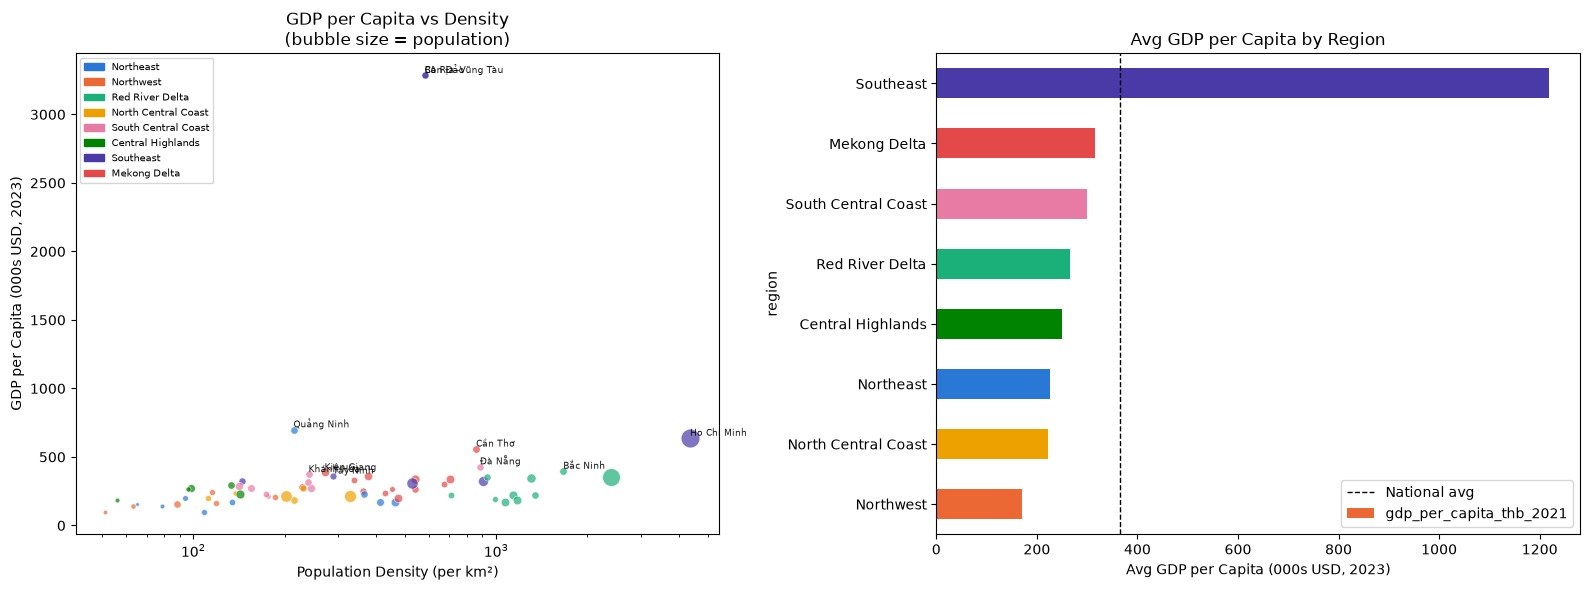

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Northeast': '#2a78d6',
    'Northwest': '#eb6834',
    'Red River Delta': '#1baf7a',
    'North Central Coast': '#eda100',
    'South Central Coast': '#e87ba4',
    'Central Highlands': '#008300',
    'Southeast': '#4a3aa7',
    'Mekong Delta': '#e34948',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD, 2023)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD, 2023)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()
os.makedirs('../../../outputs/ndt7/vietnam', exist_ok=True)
plt.savefig('../../../outputs/ndt7/vietnam/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()

### Internet Tier Distribution — Assumptions Map

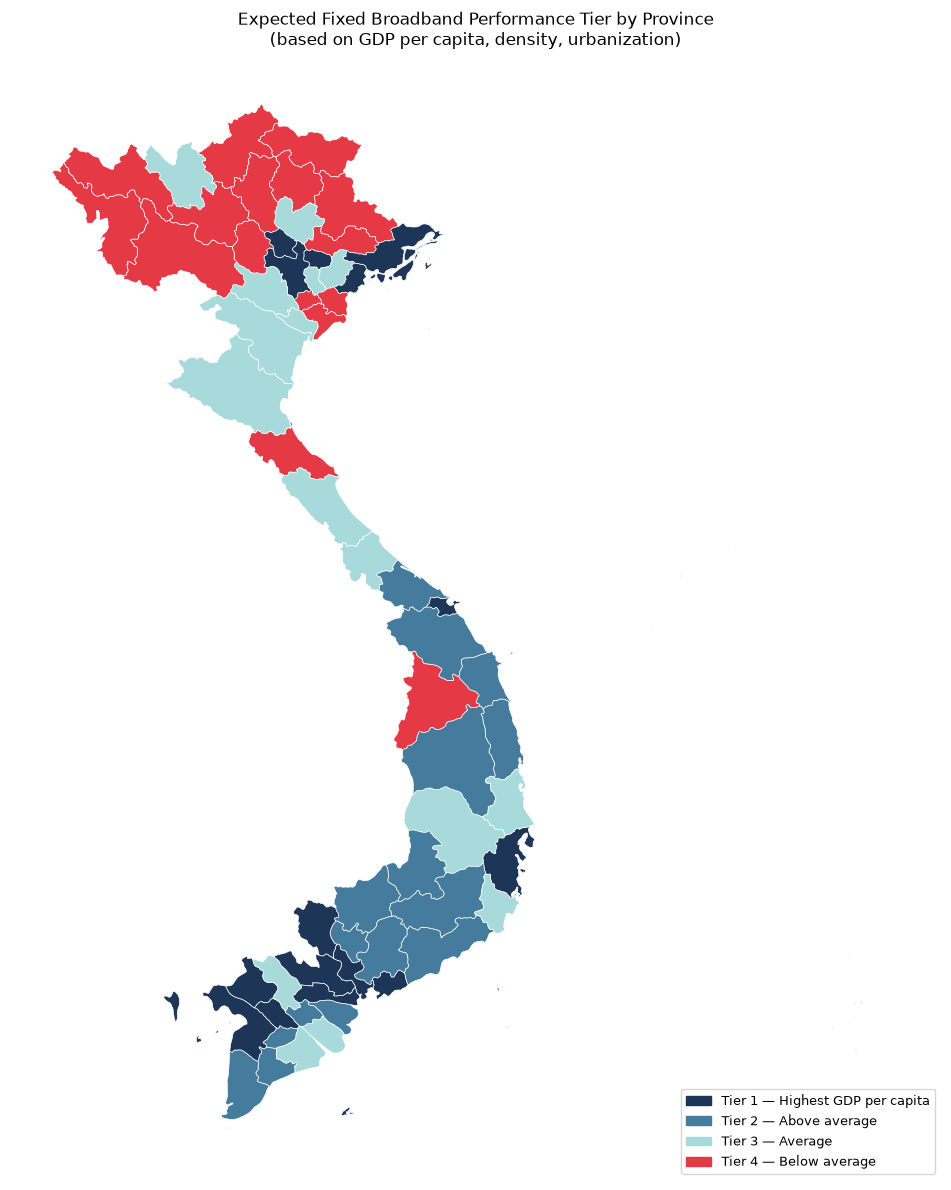

In [5]:
GEOJSON_PATH = '../../../data/geo/vietnam_provinces.geojson'
thailand_gdf = gpd.read_file(GEOJSON_PATH).to_crs(4326)

tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()
geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig('../../../outputs/ndt7/vietnam/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()

### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [6]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))

=== TOP 10 by GDP per Capita ===
    province_en              region  pop_2024  gdp_per_capita_thb_2021  internet_tier
Bà Rịa–Vũng Tàu           Southeast   1303000               3286254.54              1
        Côn Đảo           Southeast   1303000               3286254.54              1
     Quảng Ninh           Northeast   1387000                699887.25              1
    Ho Chi Minh           Southeast   9125000                638474.09              1
        Cần Thơ        Mekong Delta   1456000                559273.75              1
        Đà Nẵng South Central Coast   1294000                429834.96              1
       Bắc Ninh     Red River Delta   1447000                397659.74              1
     Kiên Giang        Mekong Delta   1789000                387388.18              1
      Khánh Hòa South Central Coast   1371000                373474.50              1
       Tây Ninh           Southeast   1207000                362573.14              1

=== BOTTOM 10 by GDP

---
# Part 1 — Broadband

## Full EDA — NDT7 Broadband, Vietnam (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [7]:
import os
os.makedirs('../../../outputs/ndt7/vietnam/', exist_ok=True)

import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../../data/exports/ndt7_vietnam_province_quarterly.csv'
GEOJSON  = '../../../data/geo/vietnam_provinces.geojson'
PROV_REF = prov_ref  # loaded in shared setup above

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")

Master shape: (746, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  63 (of 64 in reference — NDT7 has zero test volume for the rest)


In [8]:
# is_reliable already computed upstream (vietnam_ndt7_prep.ipynb, total_tests>=100 only — n_tiles dropped for NDT7, see prep notebook)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")
print("\nReliable coverage decays sharply over the study period (concentrated NDT7 volume early) — see the paper draft's NDT7 cross-validation caveat.")

Reliable province-quarters per label:
label
2023-Q1    57
2023-Q2    60
2023-Q3    58
2023-Q4    57
2024-Q1    60
2024-Q2    61
2024-Q3    59
2024-Q4    58
2025-Q1    62
2025-Q2    57
2025-Q3    54
2025-Q4    55

Overall reliable: 698 / 746 (93.6%)

Reliable coverage decays sharply over the study period (concentrated NDT7 volume early) — see the paper draft's NDT7 cross-validation caveat.


### 2. Data Quality — Coverage per Province

In [9]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(thailand_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))

Expected rows (if every province had every quarter): 768 | Actual: 746 | Missing: 22

Provinces with ZERO NDT7 test volume in any quarter (64): ['An Giang', 'Bà Rịa–Vũng Tàu', 'Bình Dương', 'Bình Phước', 'Bình Thuận', 'Bình Định', 'Bạc Liêu', 'Bắc Giang', 'Bắc Kạn', 'Bắc Ninh', 'Bến Tre', 'Cao Bằng', 'Cà Mau', 'Côn Đảo', 'Cần Thơ', 'Gia Lai', 'Ho Chi Minh', 'Hà Giang', 'Hà Nam', 'Hà Nội', 'Hà Tĩnh', 'Hòa Bình', 'Hưng Yên', 'Hải Dương', 'Hải Phòng', 'Hậu Giang', 'Khánh Hòa', 'Kiên Giang', 'Kon Tum', 'Lai Châu', 'Long An', 'Lào Cai', 'Lâm Đồng', 'Lạng Sơn', 'Nam Định', 'Nghệ An', 'Ninh Bình', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên', 'Quảng Bình', 'Quảng Nam', 'Quảng Ngãi', 'Quảng Ninh', 'Quảng Trị', 'Sóc Trăng', 'Sơn La', 'Thanh Hóa', 'Thái Bình', 'Thái Nguyên', 'Thừa Thiên Huế', 'Tiền Giang', 'Trà Vinh', 'Tuyên Quang', 'Tây Ninh', 'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái', 'Điện Biên', 'Đà Nẵng', 'Đắk Lắk', 'Đắk Nông', 'Đồng Nai', 'Đồng Tháp']

Low-test quarters (< 100 tests) — 48 of 746 province-

In [10]:
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections 3-14 below will report "
          "'no reliable data' instead of plotting.")

Filtered to reliable province-quarters: 698 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

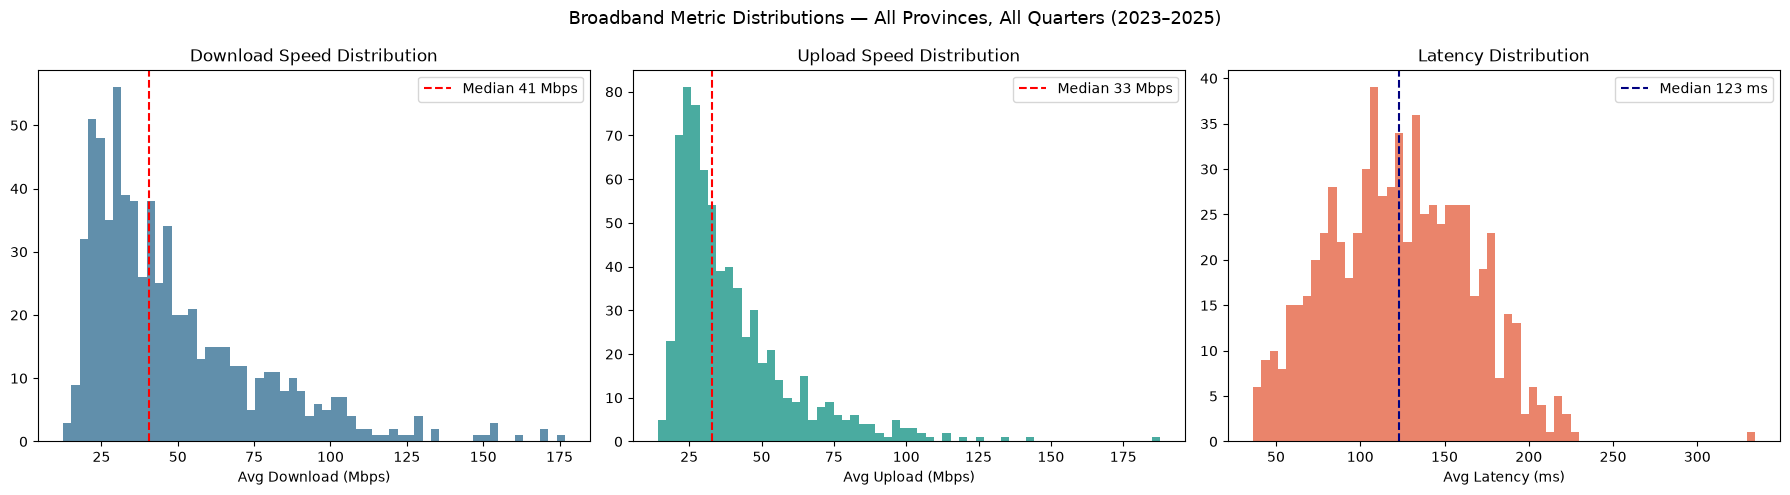

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      698.00      698.00         698.00       698.00
mean        48.67       39.77         123.31     16070.02
std         27.94       20.70          41.78    101314.60
min         12.36       14.17          36.27       106.00
25%         28.38       25.61          91.25       532.50
50%         40.62       33.06         123.29      1198.00
75%         61.86       47.38         153.74      3662.75
max        176.75      187.68         334.16   1873648.00


In [11]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../../outputs/ndt7/vietnam/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))

### 4. Province Ranking — Mean Download Speed (All Quarters)

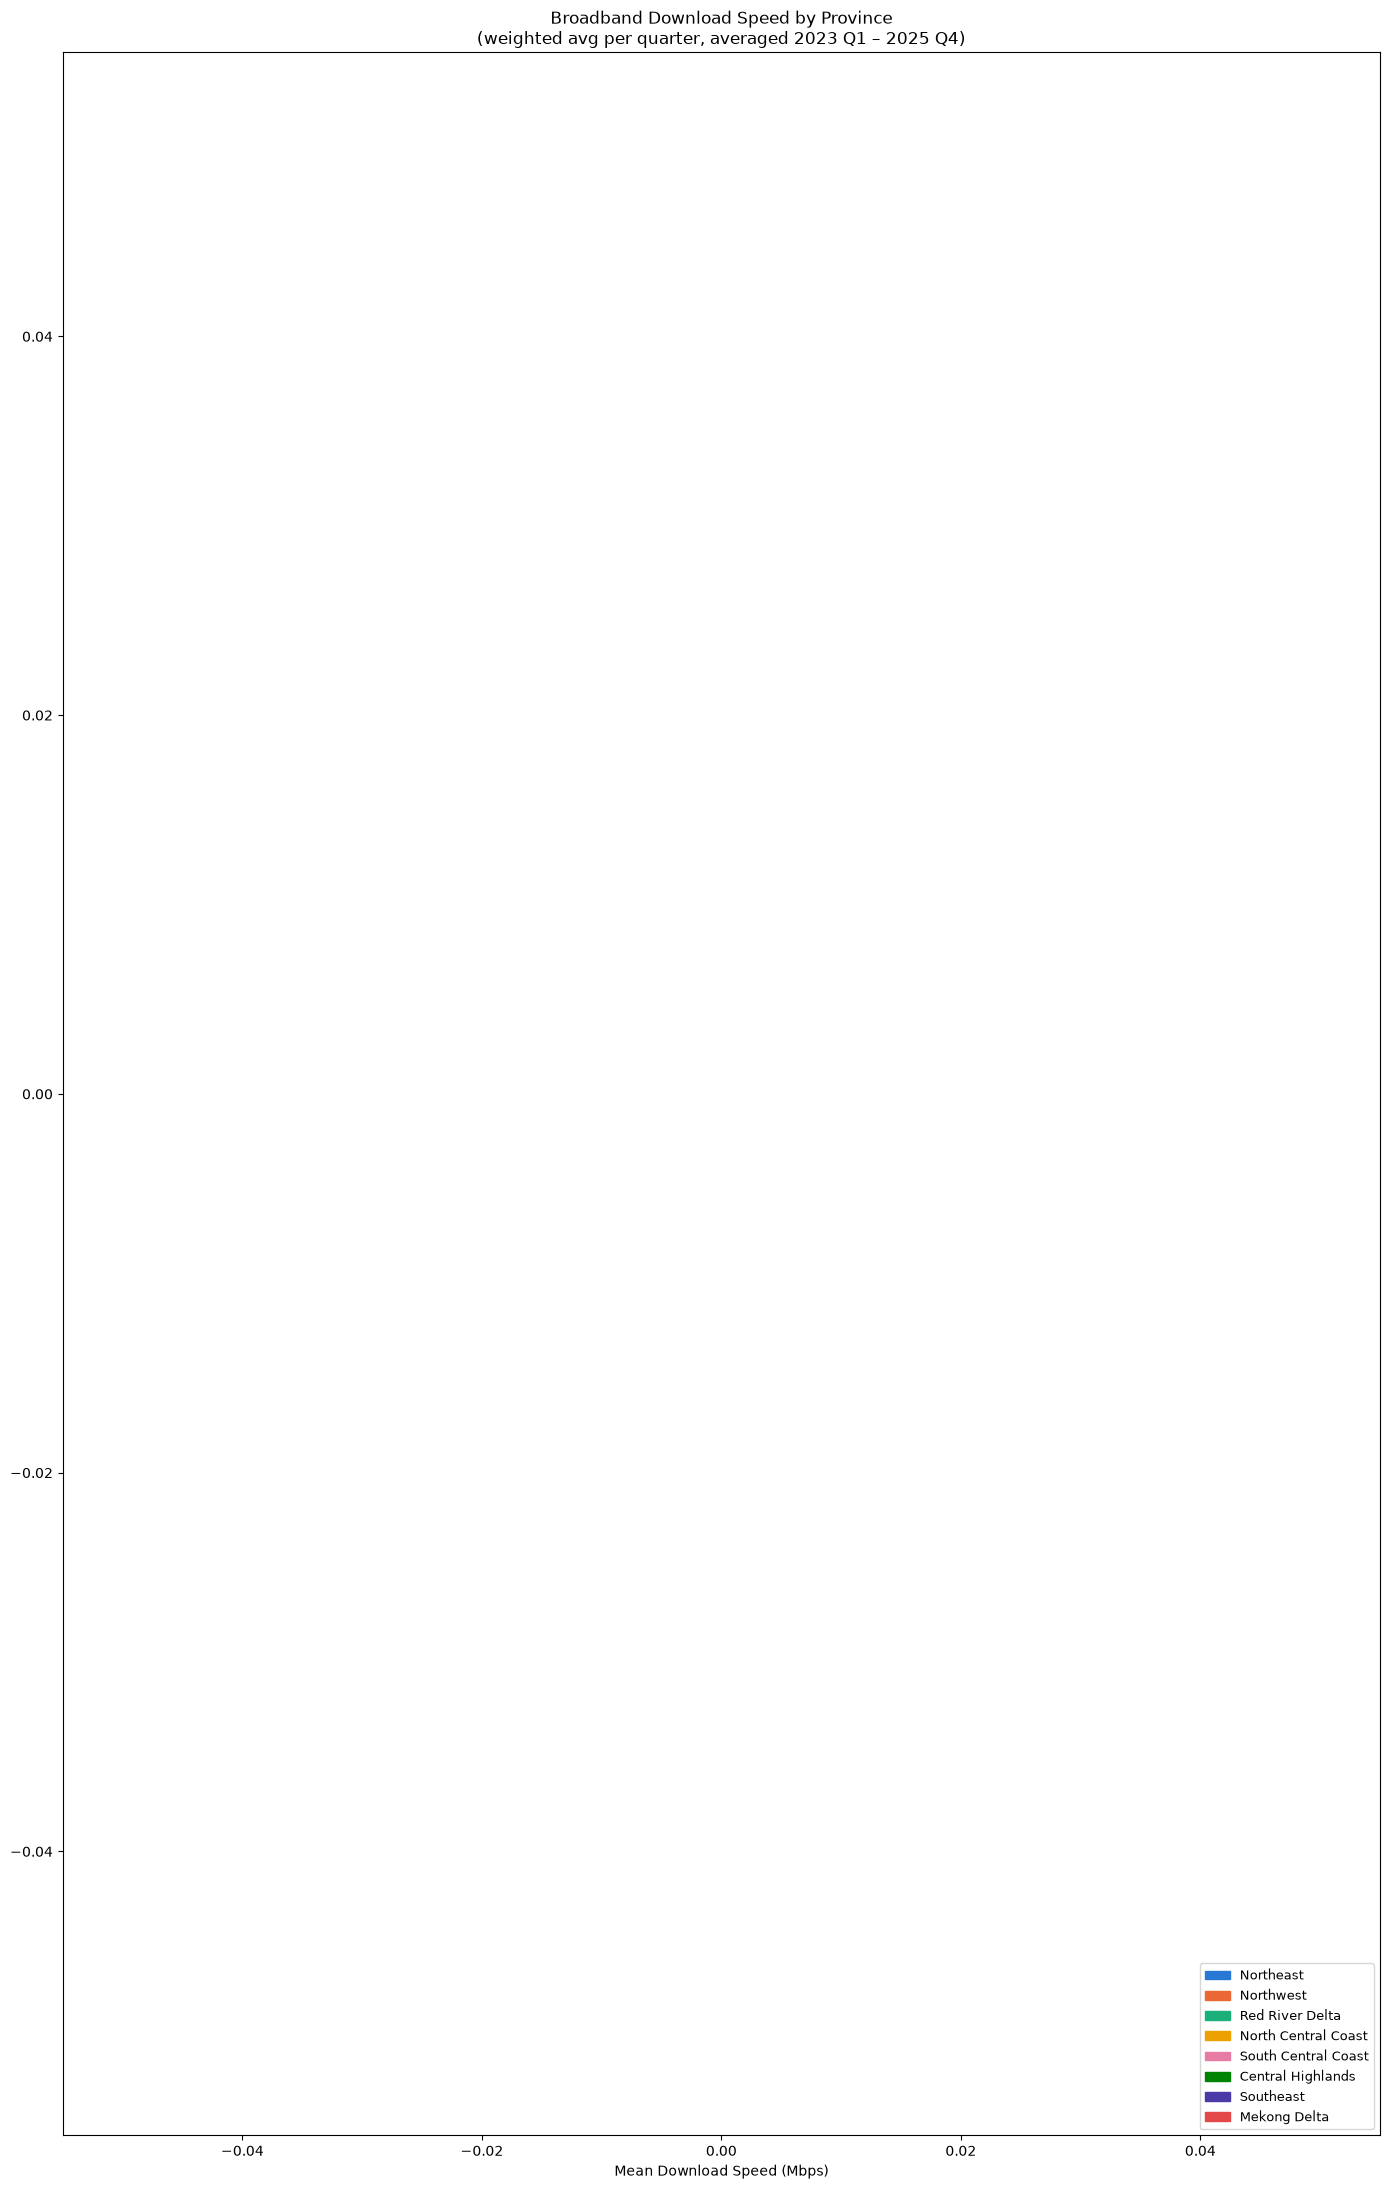

In [12]:
region_colors = {
    'Northeast': '#2a78d6',
    'Northwest': '#eb6834',
    'Red River Delta': '#1baf7a',
    'North Central Coast': '#eda100',
    'South Central Coast': '#e87ba4',
    'Central Highlands': '#008300',
    'Southeast': '#4a3aa7',
    'Mekong Delta': '#e34948',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Broadband — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 22))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5. Time Series — Download Speed Heatmap (Province × Quarter)

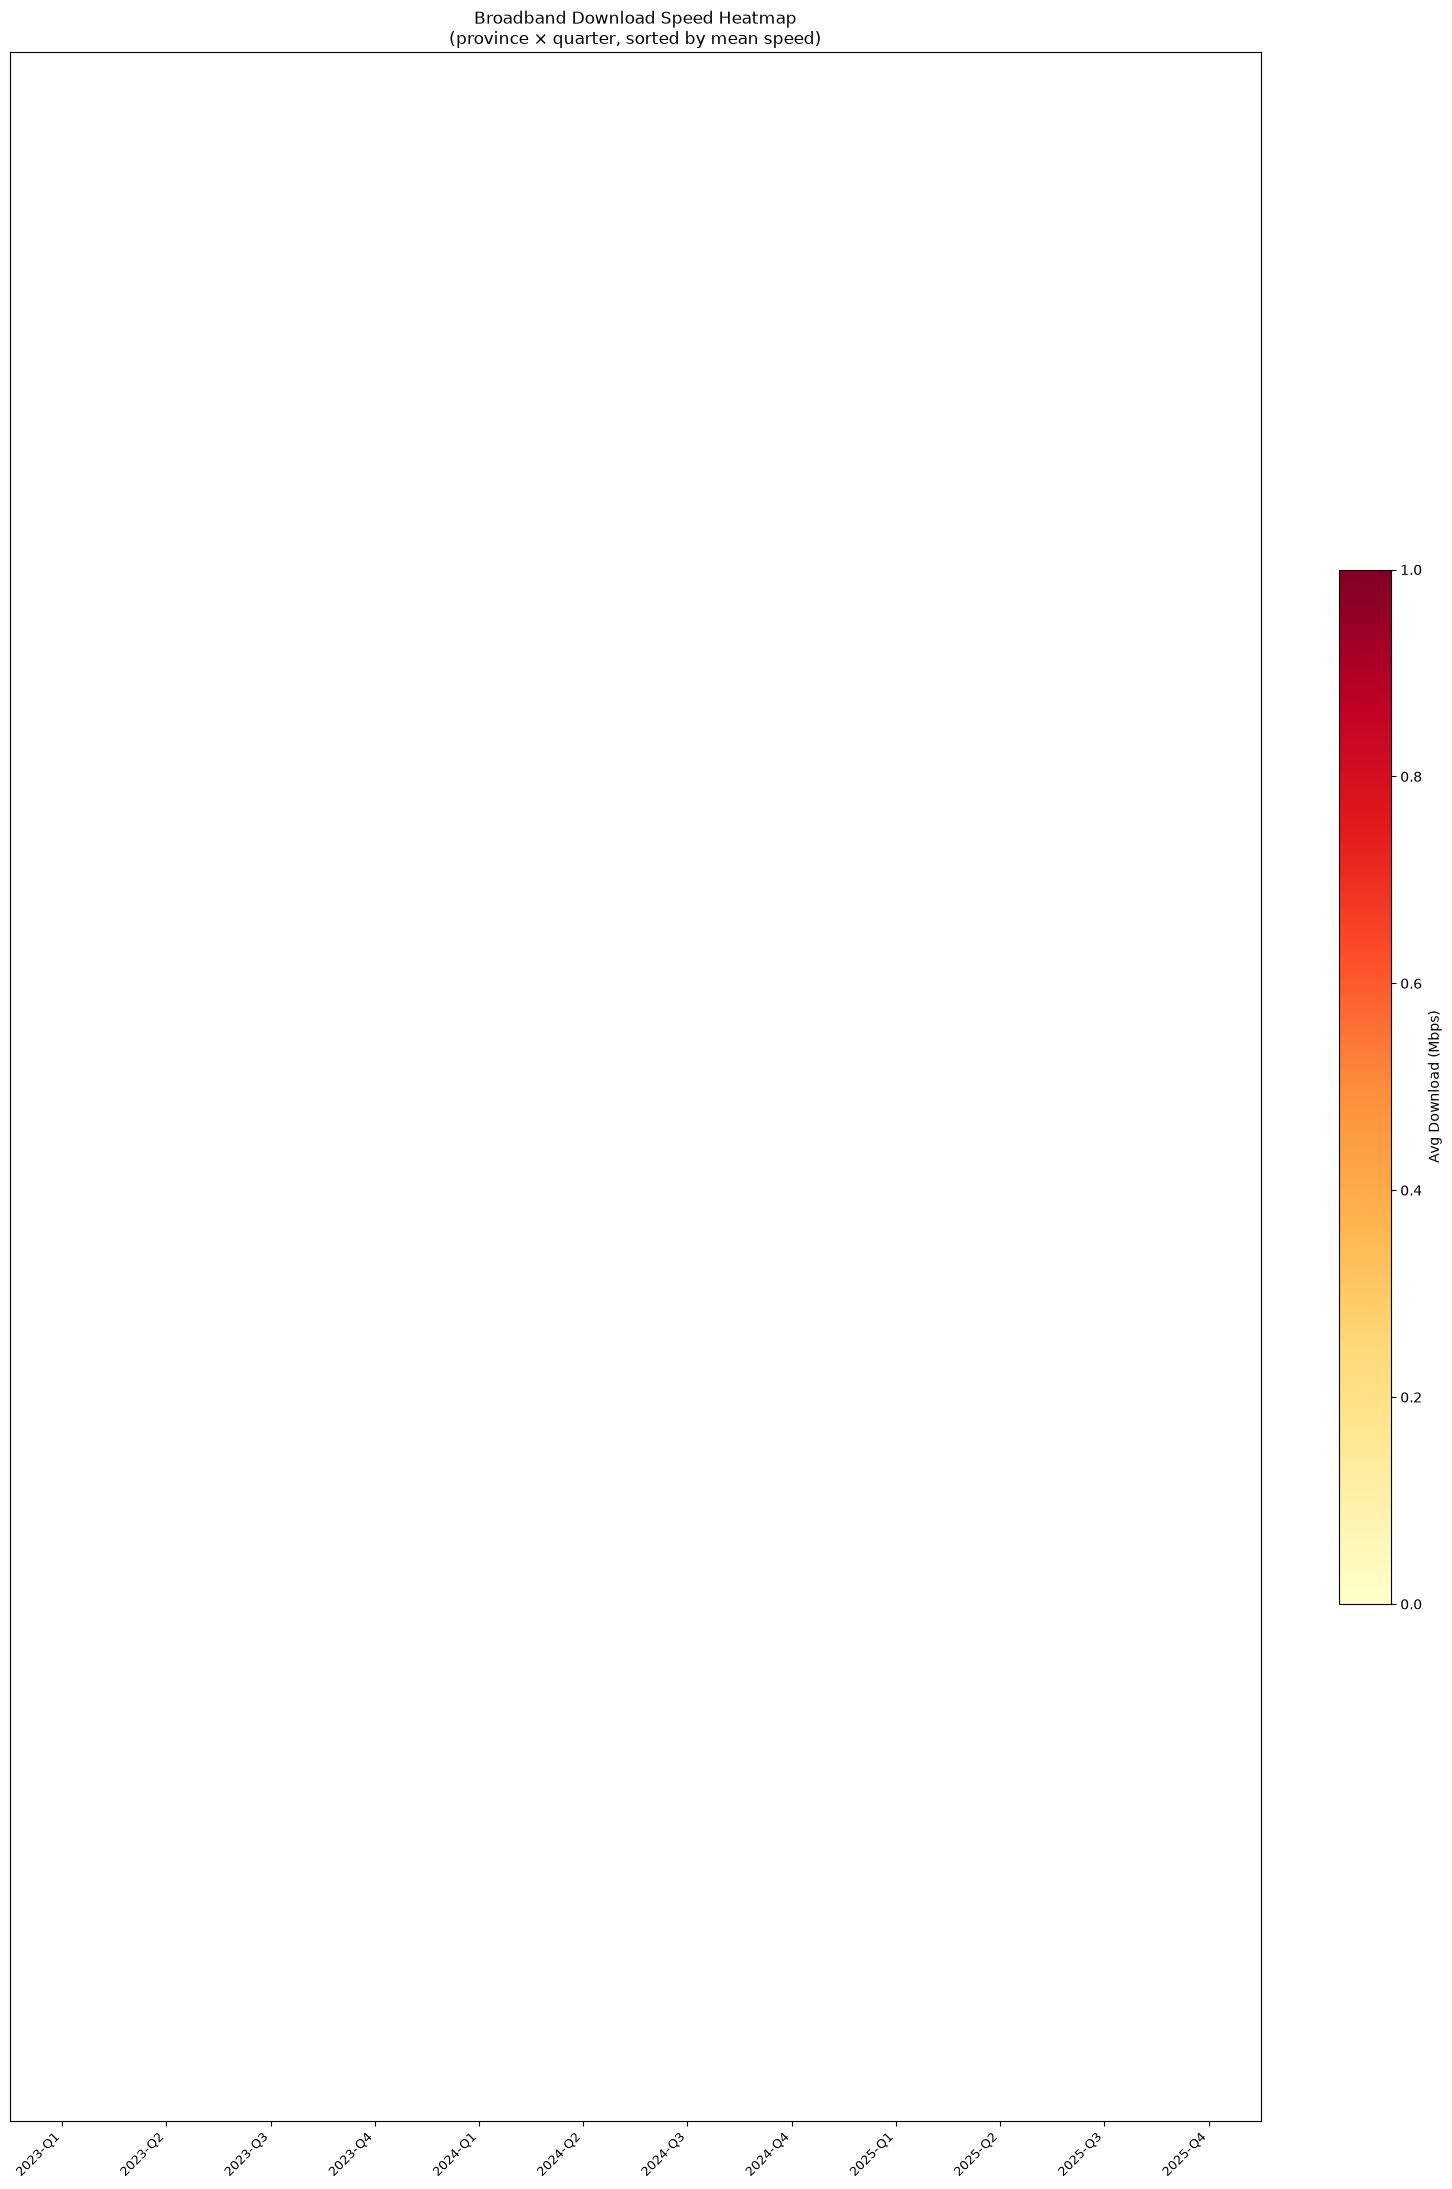

In [13]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 22))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6. Regional Comparison — Download, Upload, Latency

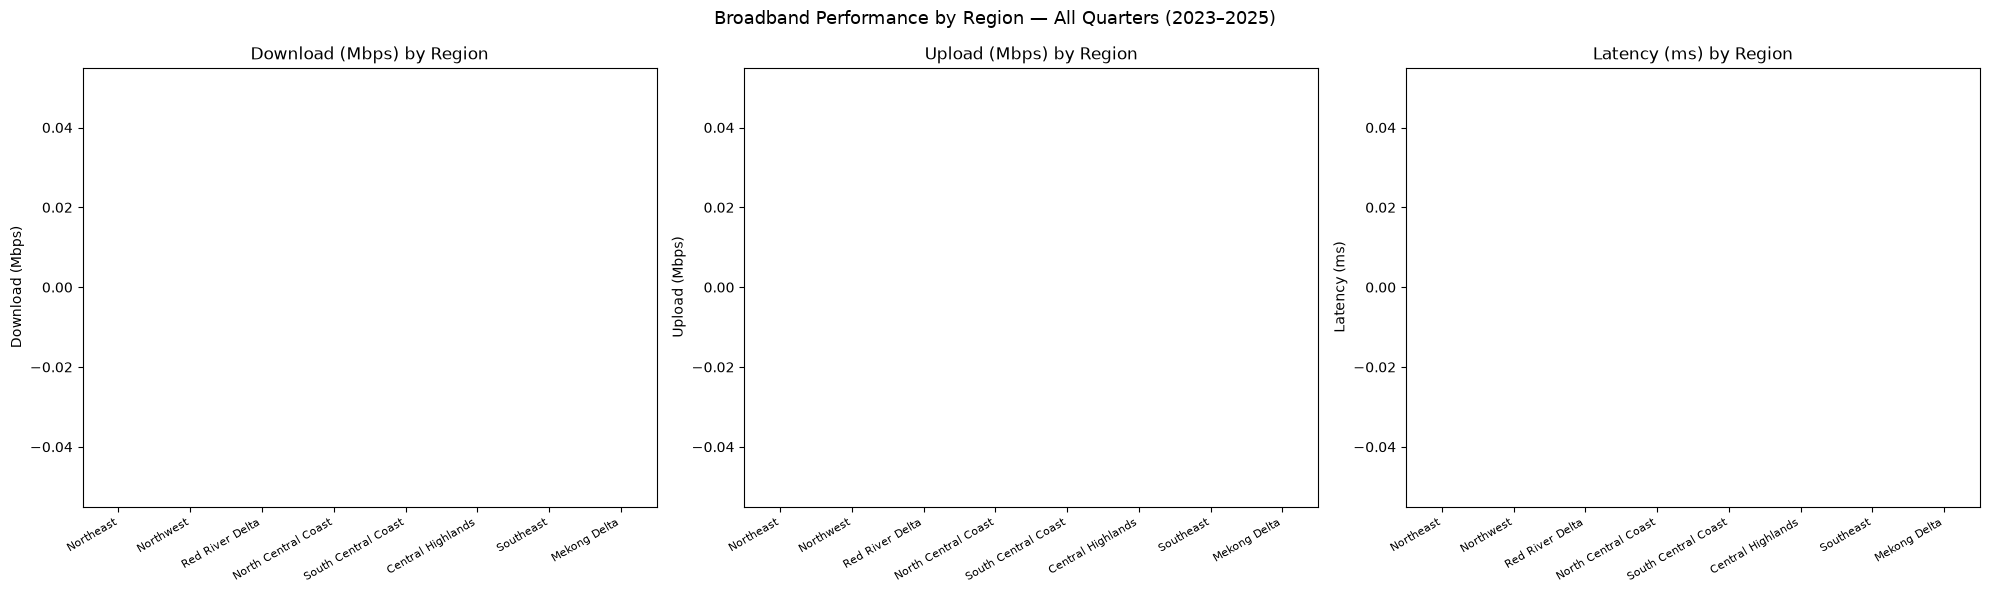

In [14]:
region_order = ['Northeast', 'Northwest', 'Red River Delta', 'North Central Coast', 'South Central Coast', 'Central Highlands', 'Southeast', 'Mekong Delta']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, label, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels(region_order, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{label} by Region')
    plt.suptitle('Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

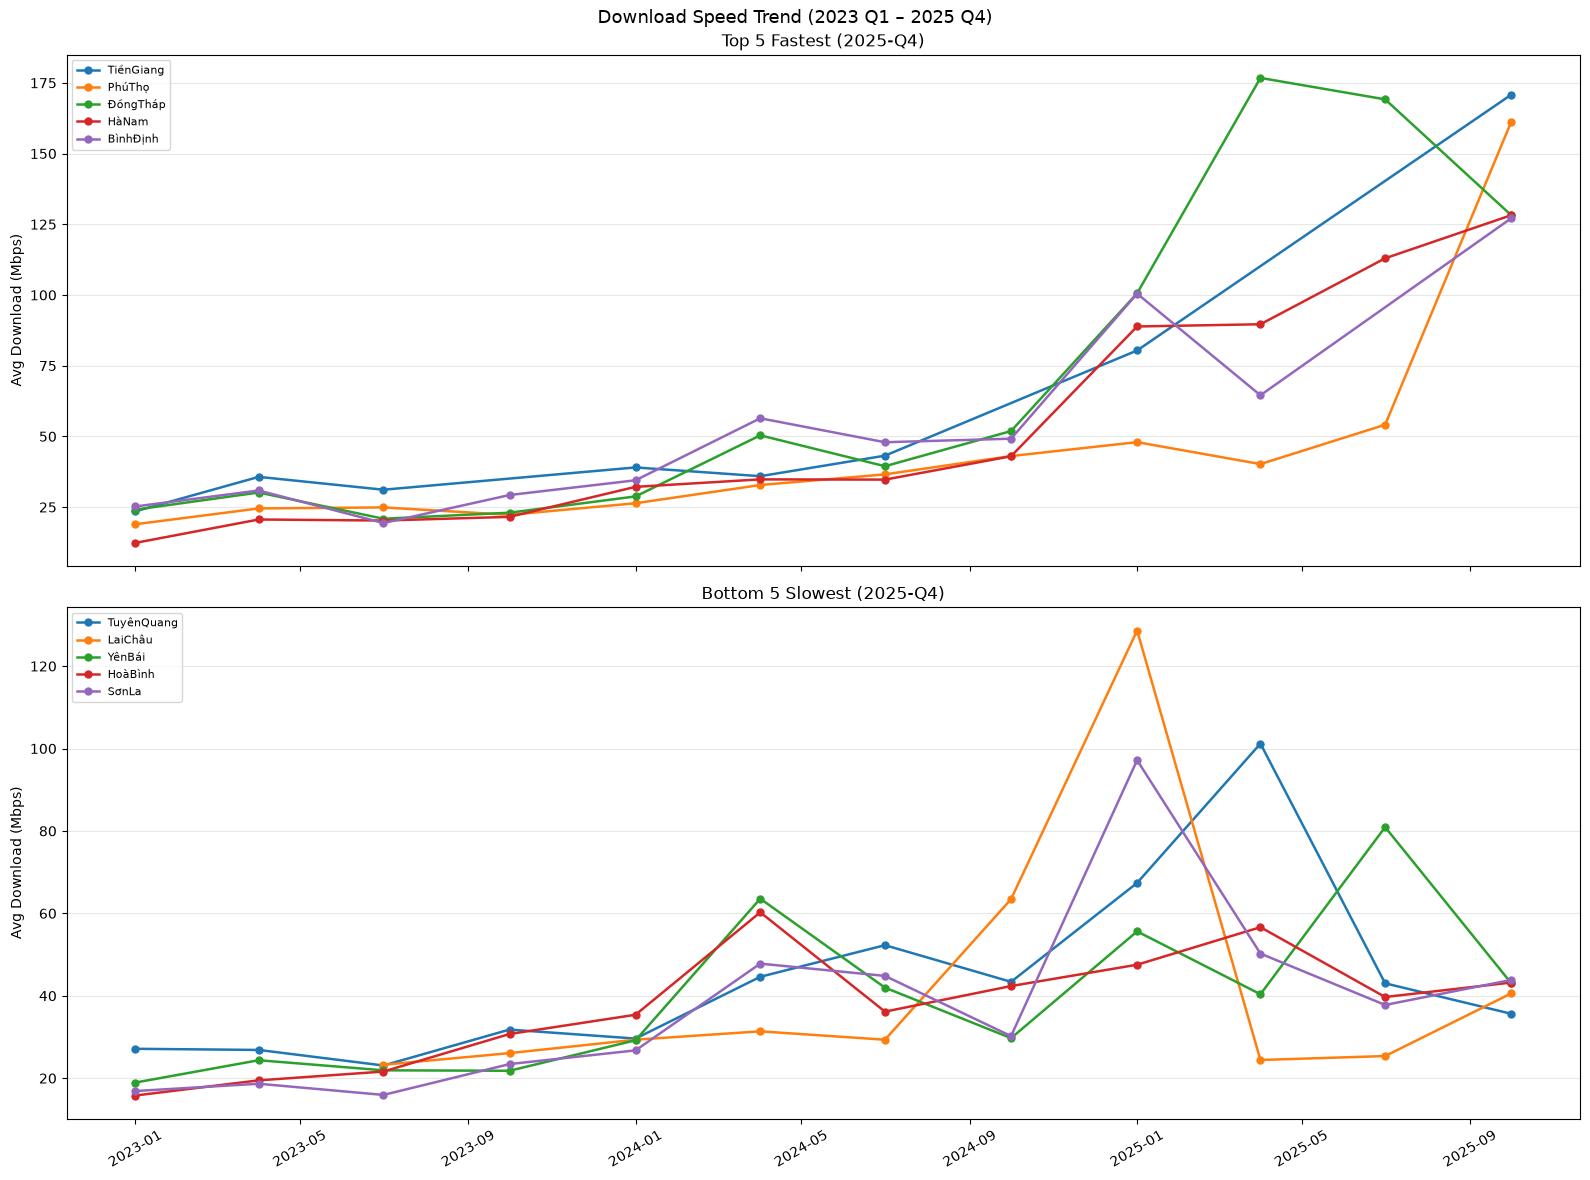

In [15]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8. GDP per Capita vs Download Speed — Does Money = Speed?

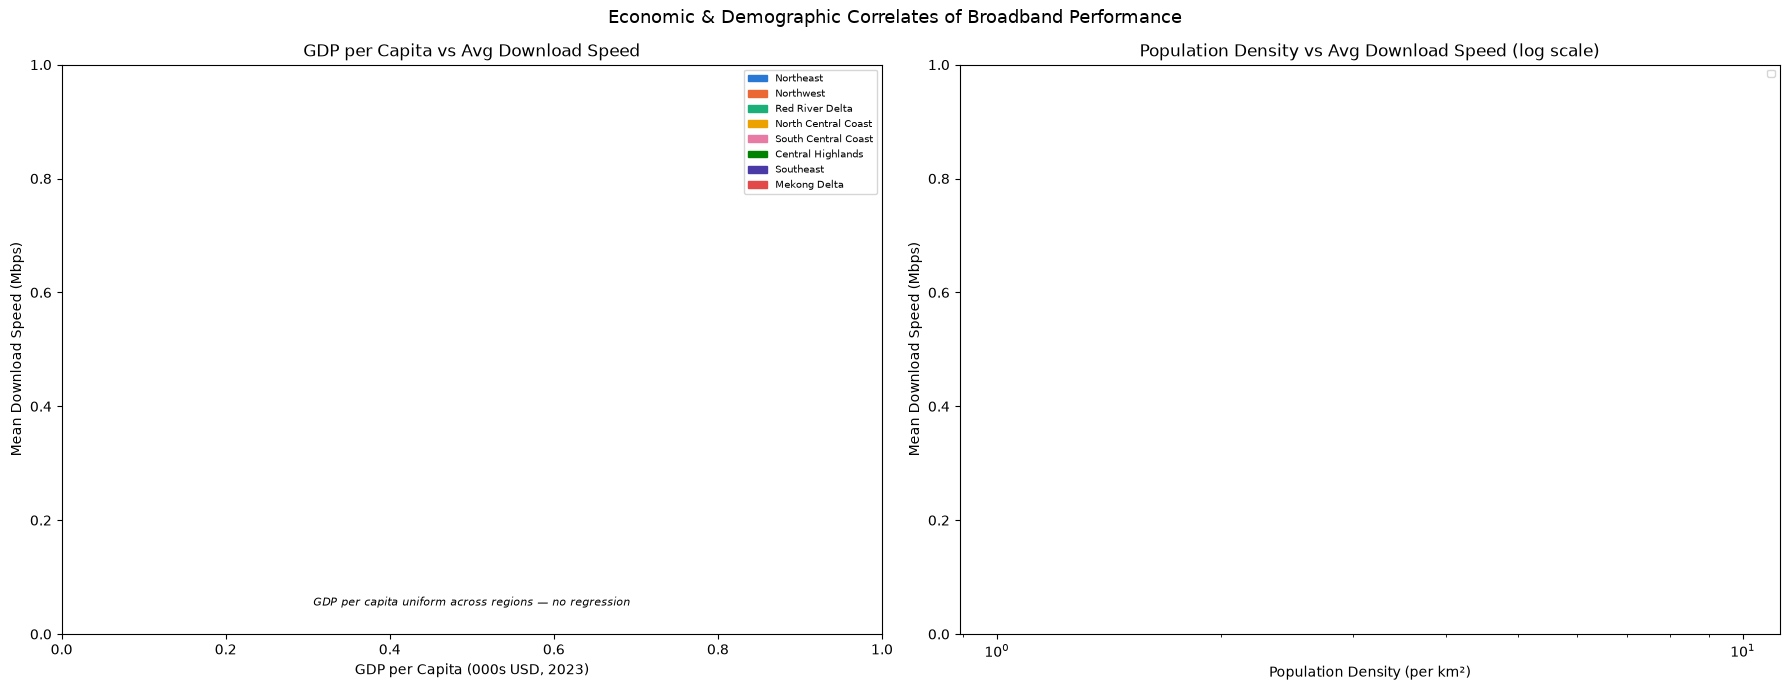

Pearson r (GDP vs download):     nan  p=nan
Pearson r (log density vs download): nan  p=nan


In [16]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Broadband — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Broadband Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")

### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [17]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Broadband — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
        print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")

No reliable data for Broadband — skipping multivariate model (need >=5 observations to fit).


### 9. Upload/Download Ratio — Symmetry Check

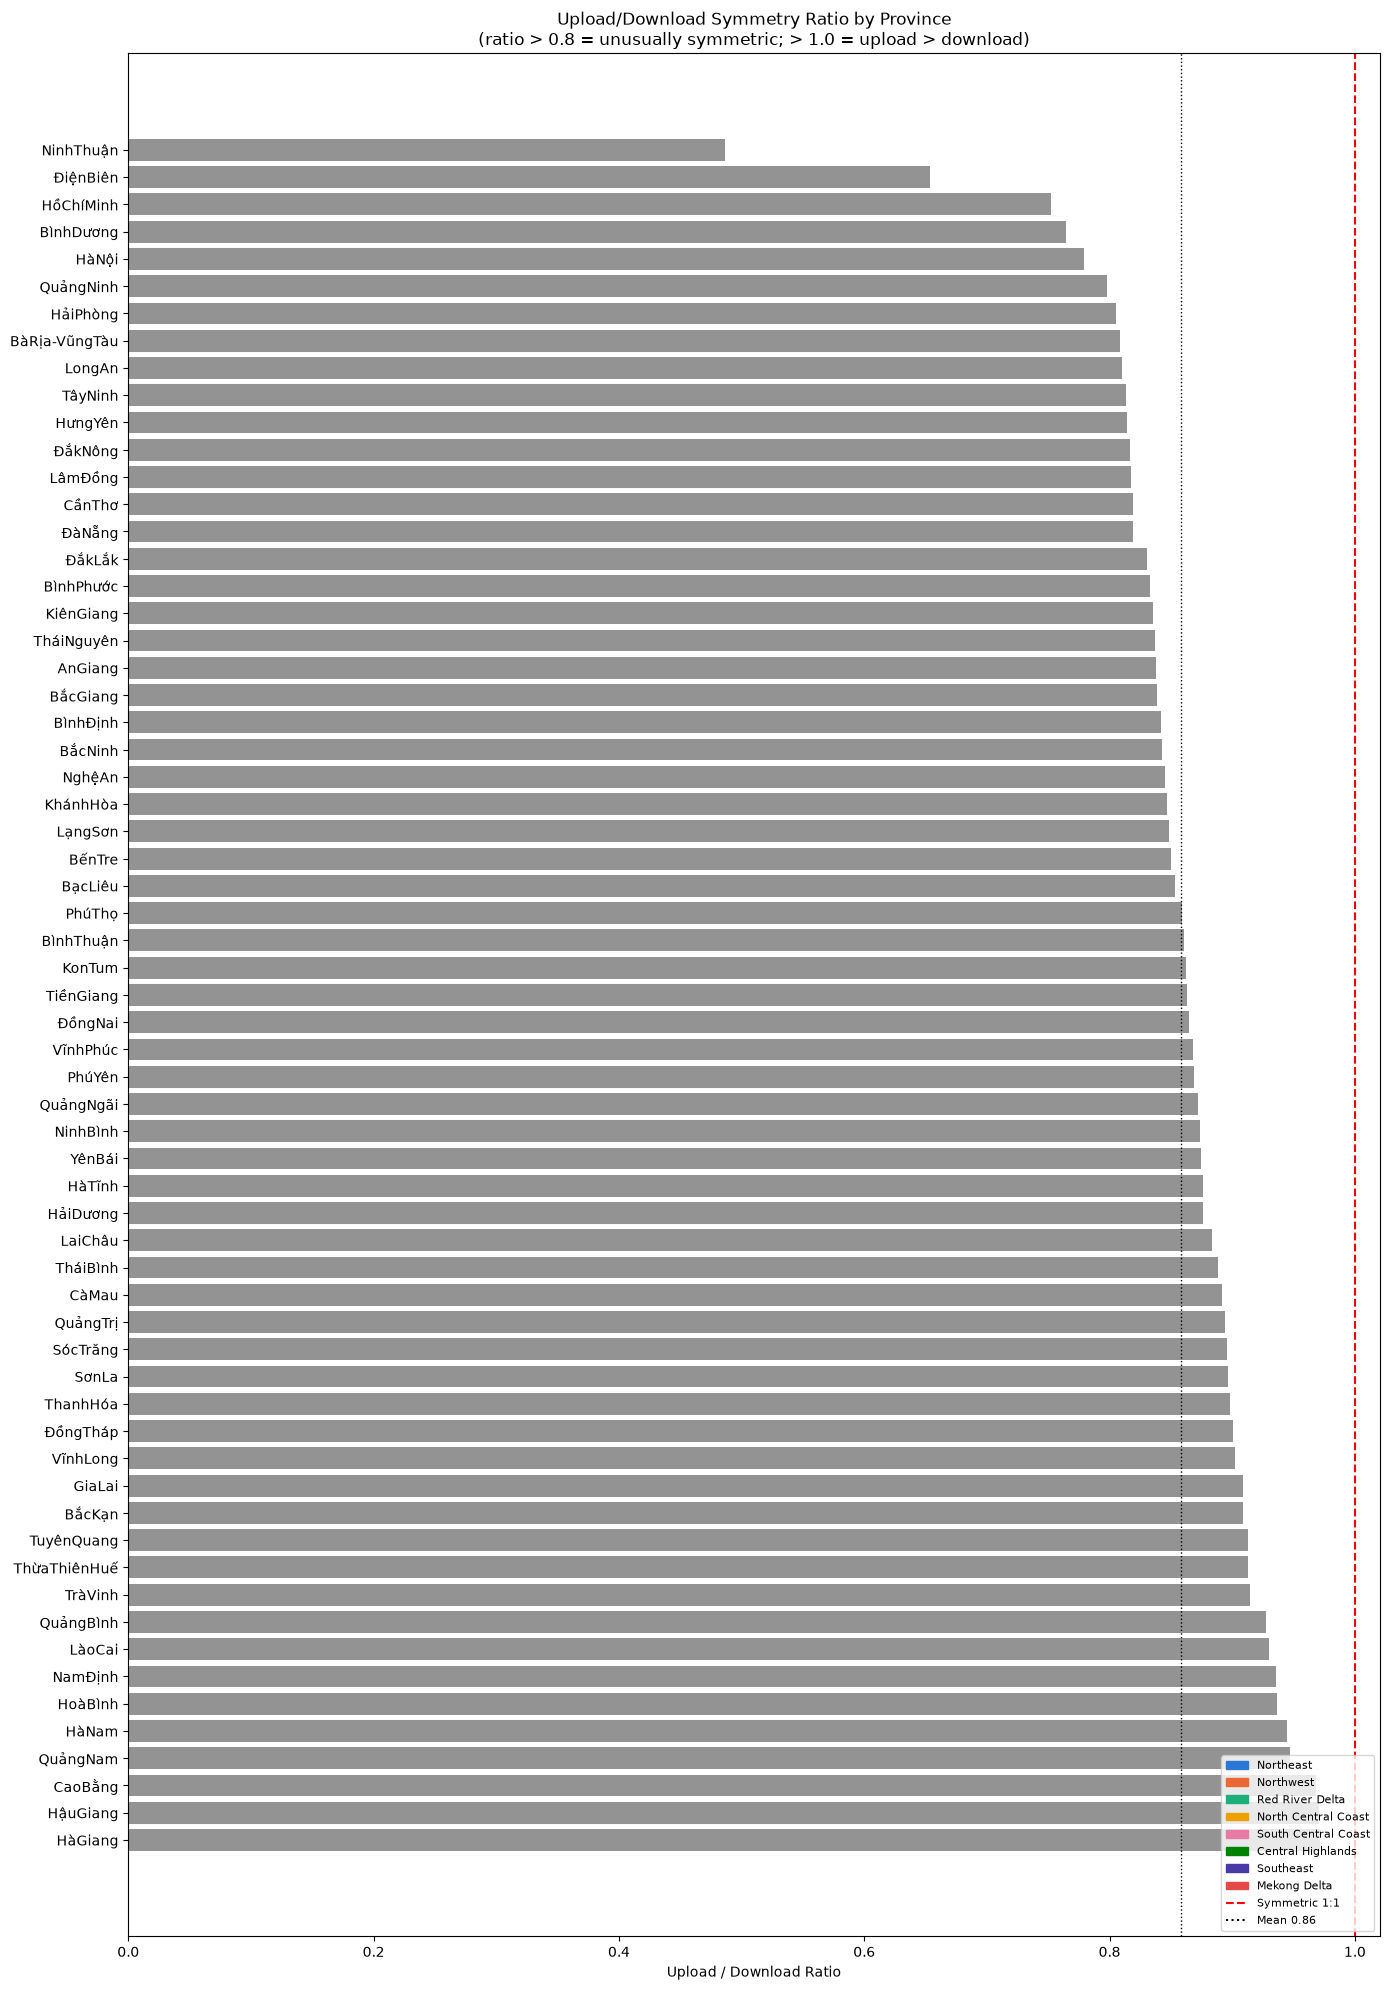

Provinces with UL/DL ratio > 0.8 (57):
         name region  ul_dl_ratio
      HàGiang    NaN     0.971889
     HậuGiang    NaN     0.970610
      CaoBằng    NaN     0.968332
     QuảngNam    NaN     0.947028
        HàNam    NaN     0.944274
      HoàBình    NaN     0.936847
      NamĐịnh    NaN     0.935834
       LàoCai    NaN     0.930045
    QuảngBình    NaN     0.927167
      TràVinh    NaN     0.914716
 ThừaThiênHuế    NaN     0.912616
   TuyênQuang    NaN     0.912531
       BắcKạn    NaN     0.908778
       GiaLai    NaN     0.908632
     VĩnhLong    NaN     0.902010
     ĐồngTháp    NaN     0.900601
     ThanhHóa    NaN     0.897973
        SơnLa    NaN     0.896785
     SócTrăng    NaN     0.896059
     QuảngTrị    NaN     0.893761
        CàMau    NaN     0.891682
     TháiBình    NaN     0.888273
      LaiChâu    NaN     0.883140
     HảiDương    NaN     0.876043
       HàTĩnh    NaN     0.875985
       YênBái    NaN     0.874527
     NinhBình    NaN     0.873772
    Quảng

In [18]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 20))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
    print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))

### 10. Province Summary — Tier & UL/DL Ratio

In [19]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Broadband — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

### 12. Full Province Summary Table

In [20]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))

Empty DataFrame
Columns: [name, region, internet_tier, mean_dl, mean_ul, mean_lat, ul_dl_ratio, mean_tests, gdp_per_capita_thb_2021]
Index: []


### 13. UL/DL Symmetry — Fiber Penetration Evidence

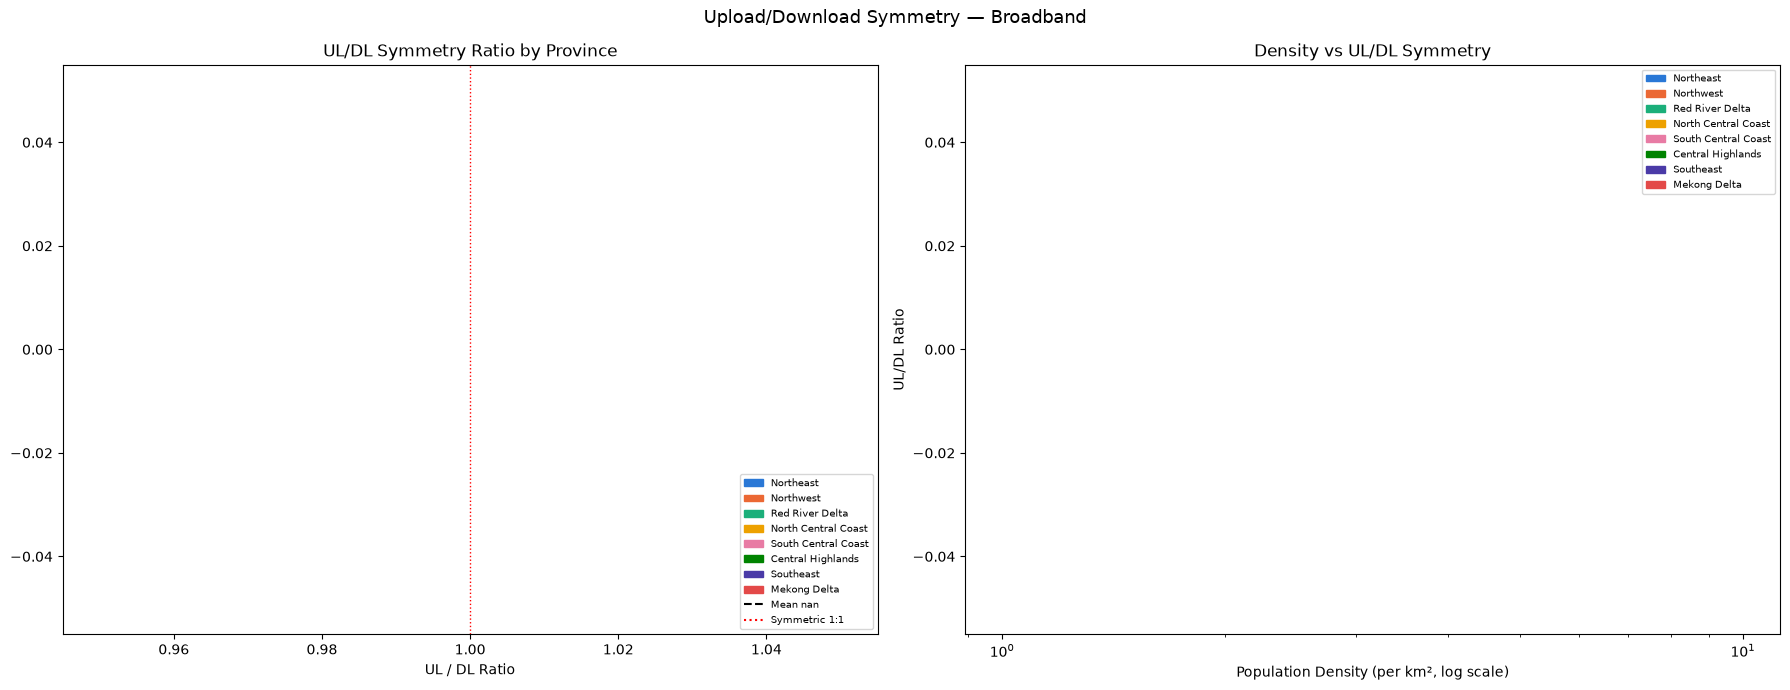

In [21]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Broadband', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

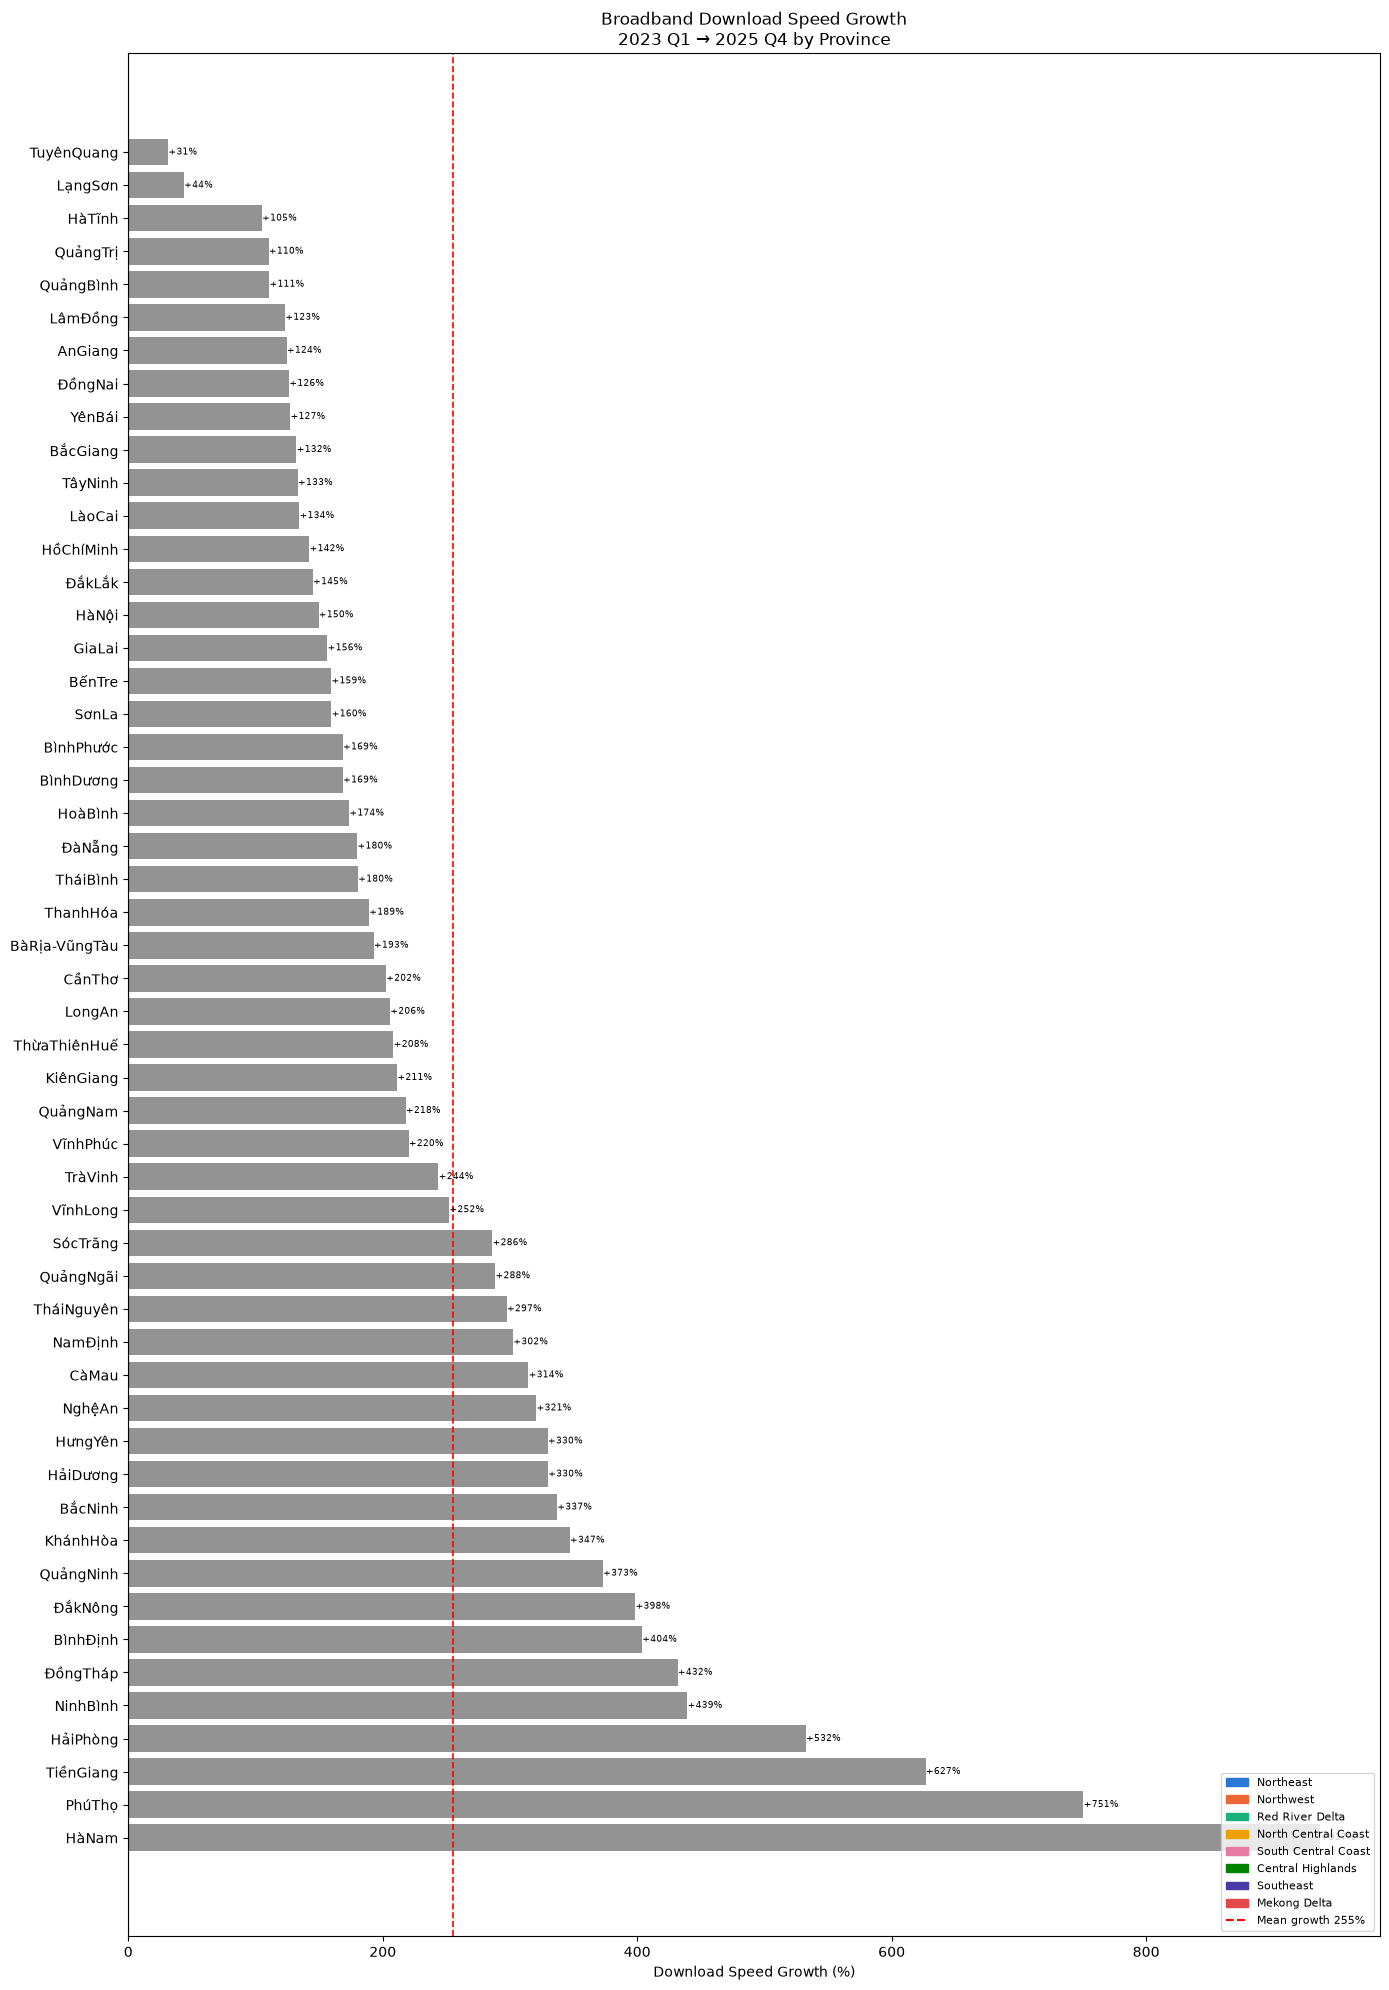

In [22]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 20))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../../outputs/ndt7/vietnam/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()

### 15. Regional Growth Index — Trajectory Shape (Normalized to First Reliable Quarter = 100)
Complements the endpoint-only growth chart above (Q1 &#8594; Q4 % change) by showing the full trajectory per region, each region's own first valid quarter rebased to 100. Regions need at least half the available quarters with reliable data to be plotted, so noisy short-history regions are dropped instead of shown misleadingly. Rolled up from province to region level — adapted from the Myanmar/Laos NDT7 notebooks' growth-index cell, which plots at province level directly since those countries have far fewer top-level admin units than the province counts tracked here.


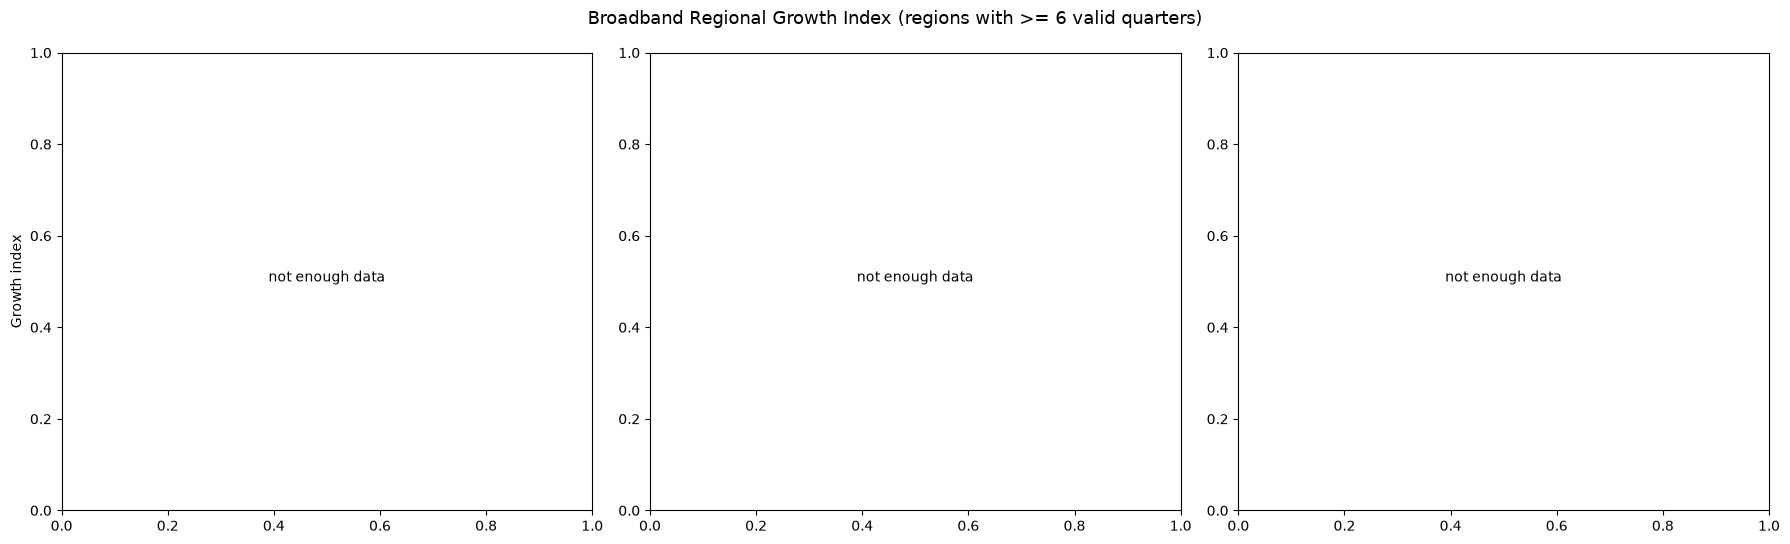

In [23]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping regional growth-index plot.")
else:
    quarter_order = sorted(master['label'].unique())
    MIN_Q = max(3, len(quarter_order) // 2)

    region_q = (
        master.groupby(['region', 'label'])
        .apply(lambda g: pd.Series({
            'avg_d_mbps': np.average(g['avg_d_mbps'], weights=g['total_tests']),
            'avg_u_mbps': np.average(g['avg_u_mbps'], weights=g['total_tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms_wt'], weights=g['total_tests']),
        }), include_groups=False)
        .reset_index()
    )

    metrics = [('avg_d_mbps', 'Download (Mbps)'), ('avg_u_mbps', 'Upload (Mbps)'), ('avg_lat_ms_wt', 'Latency (ms)')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    any_plotted = False
    for ax, (col, label) in zip(axes, metrics):
        piv = region_q.pivot(index='region', columns='label', values=col).reindex(columns=quarter_order)
        valid = piv.notna().sum(axis=1)
        keep = valid[valid >= MIN_Q].index.tolist()
        if not keep:
            ax.text(0.5, 0.5, 'not enough data', transform=ax.transAxes, ha='center')
            continue
        for reg in keep:
            s = piv.loc[reg].dropna()
            xs = [quarter_order.index(q) for q in s.index]
            ax.plot(xs, s.values / s.iloc[0] * 100, marker='o', ms=3, lw=1.3,
                    color=region_colors.get(reg, 'gray'), label=reg)
            any_plotted = True
        ax.axhline(100, color='grey', ls='--', lw=1)
        step = max(1, len(quarter_order) // 6)
        ax.set_xticks(range(0, len(quarter_order), step))
        ax.set_xticklabels([quarter_order[i] for i in range(0, len(quarter_order), step)], rotation=45, ha='right', fontsize=8)
        ax.set_title(f'{label}\n(region: own 1st valid quarter = 100)', fontsize=10)
    axes[0].set_ylabel('Growth index')
    if any_plotted:
        axes[0].legend(fontsize=7, ncol=2, loc='upper left')
    plt.suptitle(f'Broadband Regional Growth Index (regions with >= {MIN_Q} valid quarters)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/21_growth_index_regional.png', dpi=150, bbox_inches='tight')
    plt.show()


### 15.5 Measured Speed Choropleth — Actual NDT7 Download Speed by Province
The "Internet Tier" map earlier in this notebook is a GDP-based *expectation*. This map is the actual measured NDT7 average, on the same province geometry, so the two can be compared directly. Adapted from the Myanmar/Laos NDT7 notebooks' choropleth cell (re-based here on `master`'s aggregated province averages instead of a live DuckDB query, since this pipeline works off the pre-aggregated CSV export, not the raw parquet).


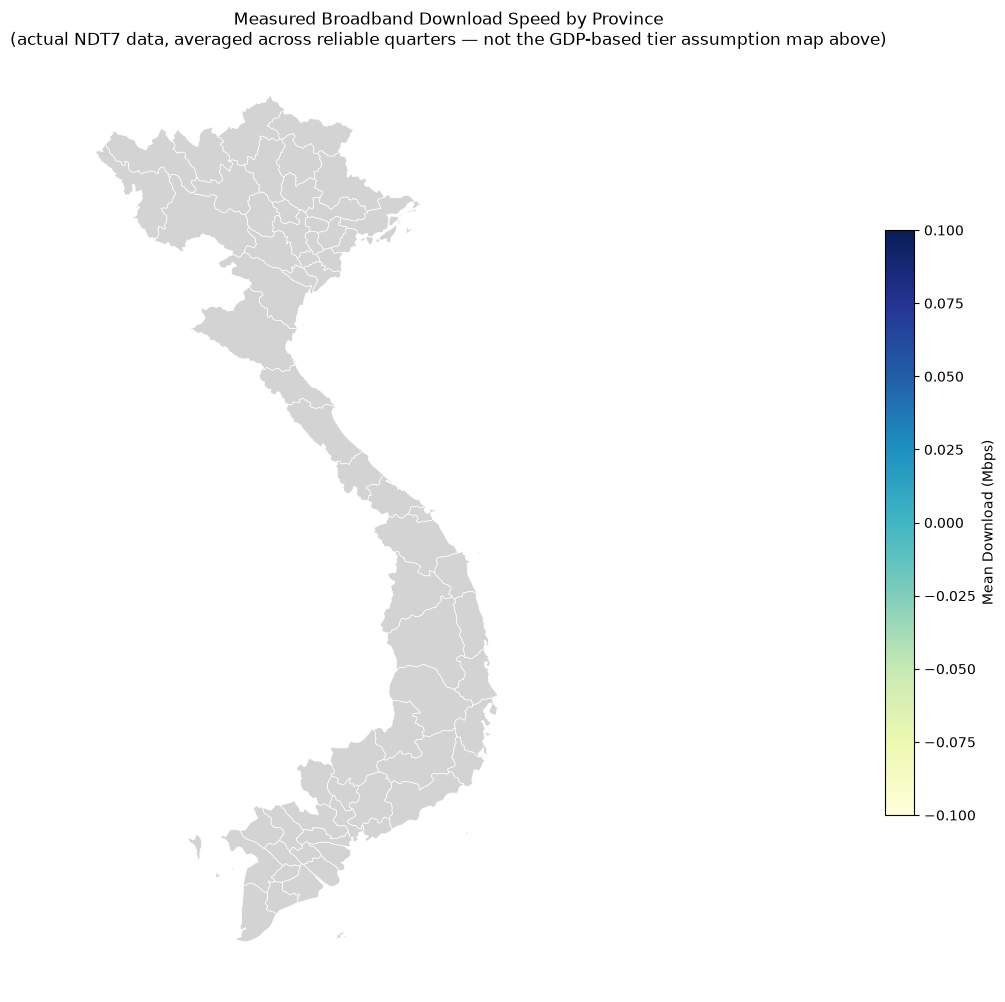

In [24]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping measured-speed choropleth.")
else:
    prov_speed = (
        master.groupby('name')
        .agg(avg_d_mbps=('avg_d_mbps', 'mean'), total_tests=('total_tests', 'sum'))
        .reset_index()
    )
    geo_speed = thailand_gdf.merge(prov_speed, on='name', how='left')

    fig, ax = plt.subplots(figsize=(10, 12))
    geo_speed.plot(
        column='avg_d_mbps', ax=ax, cmap='YlGnBu', legend=True,
        edgecolor='white', linewidth=0.5,
        legend_kwds={'shrink': 0.5, 'label': 'Mean Download (Mbps)'},
        missing_kwds={'color': 'lightgrey', 'label': 'no reliable data'},
    )
    ax.set_title('Measured Broadband Download Speed by Province\n(actual NDT7 data, averaged across reliable quarters — not the GDP-based tier assumption map above)', fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/22_speed_choropleth.png', dpi=150, bbox_inches='tight')
    plt.show()


### 16. City Focus — Capital + Top Cities by Test Volume (Broadband)
No population reference file exists in this repo, so cities are selected by raw NDT7 test
volume (a reasonable proxy for urban activity) rather than a hardcoded population list —
adapted from the Myanmar/Laos NDT7 notebooks' city-focus section, which uses a manually
curated `TOP_CITIES` population list. Capital city is flagged in red.

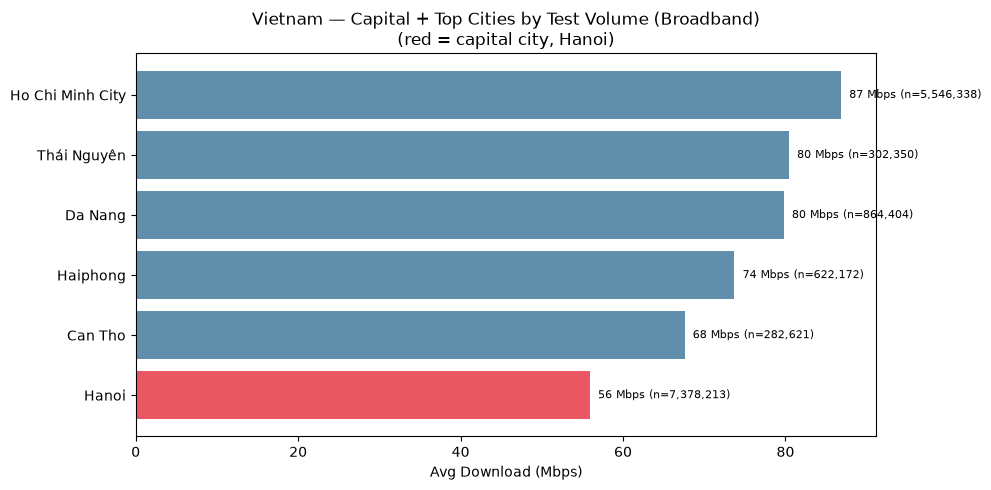

            city  n_user  avg_d_mbps  avg_u_mbps  avg_lat_ms
           Hanoi 7378213        55.9        35.4       152.5
         Can Tho  282621        67.6        50.4       102.7
        Haiphong  622172        73.7        41.0       128.0
         Da Nang  864404        79.8        58.2       136.5
     Thái Nguyên  302350        80.4        34.5       187.6
Ho Chi Minh City 5546338        86.9        59.7        97.3


In [25]:
import duckdb

_con = duckdb.connect()
_top_cities = _con.execute(f"""
    SELECT city,
           COUNT(*) AS n_user,
           AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps,
           AVG(mean_throughput_mbps) FILTER (WHERE type='upload')   AS avg_u_mbps,
           AVG(CASE WHEN min_rtt < 2000 THEN min_rtt END) AS avg_lat_ms
    FROM read_parquet('{RAW_ISP_PARQUET}')
    WHERE network_type = 'broadband' AND city IS NOT NULL AND city != ''
    GROUP BY city
    ORDER BY n_user DESC
    LIMIT 6
""").df()

if _top_cities.empty:
    print("No Broadband city-level data available — skipping city focus.")
else:
    _top_cities['is_capital'] = _top_cities['city'] == 'Hanoi'
    _top_cities = _top_cities.sort_values('avg_d_mbps', ascending=True)
    _colors = ['#e63946' if c else '#457b9d' for c in _top_cities['is_capital']]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(_top_cities['city'], _top_cities['avg_d_mbps'], color=_colors, alpha=0.85)
    for bar, (_, row) in zip(bars, _top_cities.iterrows()):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{row['avg_d_mbps']:.0f} Mbps (n={row['n_user']:,})", va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Vietnam — Capital + Top Cities by Test Volume (Broadband)\n(red = capital city, Hanoi)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/23_city_focus.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(_top_cities[['city','n_user','avg_d_mbps','avg_u_mbps','avg_lat_ms']].round(1).to_string(index=False))

### 17. Per-ISP Ranking — Top ISPs by Test Volume (Broadband)
Top 15 ISPs (min 100 tests) ranked by average download speed, bar length shows speed and
label shows test volume — adapted from the Myanmar/Laos NDT7 notebooks' per-ISP section.

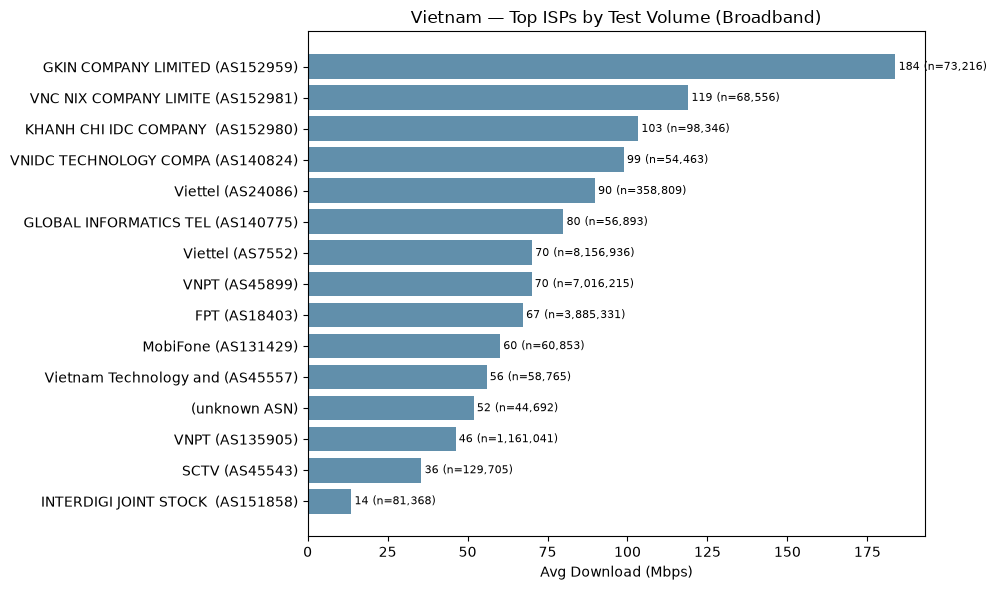

In [26]:
_isp_tbl = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เท่านั้น (HANDOFF ข้อ 1): ip-api คืนชื่อองค์กรลูกค้าสำหรับ leased line
    -- เช่น AS4750 มีชื่อ isp ถึง 420 ชื่อ และชื่อเดียวกันก็กินหลาย ASN (TRUE INTERNET = 9 ASN)
    -- operator/as_name ใช้เป็นป้ายแสดงผลเท่านั้น
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n,
               AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps
        FROM read_parquet('{RAW_ISP_PARQUET}')
        WHERE network_type = 'broadband'
        GROUP BY 1
    )
    -- ต่อรหัส ASN ท้ายป้าย: 1 แบรนด์มีได้หลาย ASN (ไทย True=2, AIS=3, NT=3, 3BB=2)
    -- ถ้าป้ายซ้ำ แกน categorical ของ matplotlib จะยุบแท่งทับกัน
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown ASN)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n, avg_d_mbps
    FROM g
    WHERE n >= 100
    ORDER BY n DESC
    LIMIT 15
""").df()

if _isp_tbl.empty:
    print("No ISP meets the n>=100 test threshold for Broadband — skipping per-ISP ranking.")
else:
    _isp_tbl = _isp_tbl.sort_values('avg_d_mbps', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.4*len(_isp_tbl))))
    ax.barh(_isp_tbl['isp'].str.slice(0, 40), _isp_tbl['avg_d_mbps'], color='#457b9d', alpha=0.85)
    for yi, (_, row) in enumerate(_isp_tbl.iterrows()):
        ax.text(row['avg_d_mbps'] + 1, yi, f"{row['avg_d_mbps']:.0f} (n={row['n']:,})", va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Vietnam — Top ISPs by Test Volume (Broadband)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/24_per_isp.png', dpi=150, bbox_inches='tight')
    plt.show()

### 18. Market Share / HHI — ISP Concentration (Broadband)
Top 8 ISPs + "Others" + "(unknown ISP)" by share of tests. HHI (Herfindahl-Hirschman Index):
<1500 = competitive, 1500-2500 = moderate concentration, >2500 = highly concentrated —
adapted from the Myanmar/Laos NDT7 notebooks' market-share section.

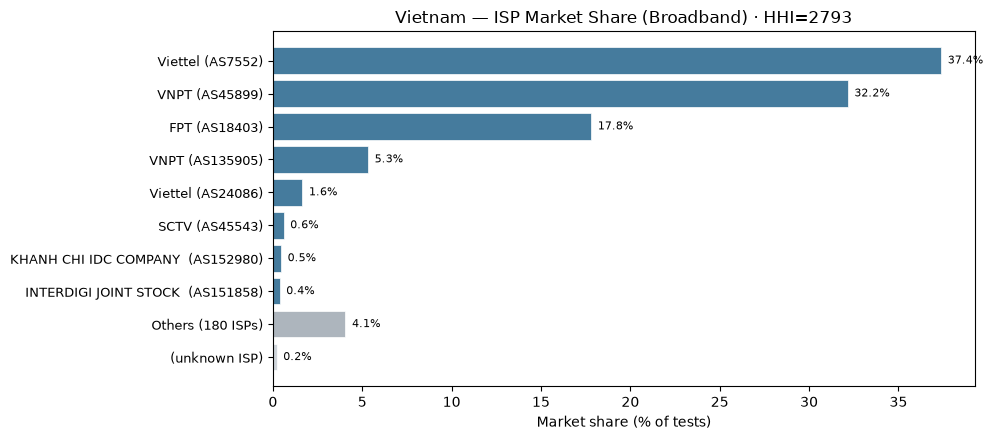

HHI=2793 (highly concentrated) | Top5 share=94.3% | unknown=0.2%


In [27]:
_mkt = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เหมือน §17 (ดูเหตุผลข้างบน) — HHI อ่อนไหวกับการแตกชื่อมาก
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n
        FROM read_parquet('{RAW_ISP_PARQUET}')
        WHERE network_type = 'broadband'
        GROUP BY 1
    )
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n
    FROM g ORDER BY n DESC
""").df()

if _mkt.empty:
    print("No Broadband data — skipping market share.")
else:
    _total = _mkt['n'].sum()
    _mkt['share'] = 100 * _mkt['n'] / _total
    _named = _mkt[_mkt['isp'] != '(unknown)'].reset_index(drop=True)
    _unknown_share = float(_mkt.loc[_mkt['isp'] == '(unknown)', 'share'].sum())
    TOPN = 8
    _top = _named.head(TOPN)
    _others_share = float(_named['share'].iloc[TOPN:].sum())
    # HHI ต้องคิดบนฐานที่มีชื่อเท่านั้น — เดิมหารด้วย _total ที่รวม (unknown) ทำให้ HHI ต่ำกว่าจริง
    _named_share = 100.0 * _named['n'] / _named['n'].sum()
    _hhi = float((_named_share ** 2).sum())

    _rows = list(zip(_top['isp'].str.slice(0, 44), _top['share']))
    if _others_share > 0:
        _rows.append((f"Others ({len(_named) - len(_top)} ISPs)", _others_share))
    if _unknown_share > 0:
        _rows.append(("(unknown ISP)", _unknown_share))
    _labels = [r[0] for r in _rows][::-1]
    _vals = [r[1] for r in _rows][::-1]
    _colors = ['#adb5bd' if l.startswith('Others') else '#ced4da' if l.startswith('(unknown') else '#457b9d' for l in _labels]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(_vals))))
    y = list(range(len(_vals)))
    ax.barh(y, _vals, color=_colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(_labels, fontsize=9)
    for yi, v in zip(y, _vals):
        ax.text(v + max(_vals) * 0.01, yi, f"{v:.1f}%", va='center', fontsize=8)
    ax.set_xlabel('Market share (% of tests)')
    ax.set_title(f"Vietnam — ISP Market Share (Broadband) \u00b7 HHI={_hhi:.0f}")
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/25_market_share.png', dpi=150, bbox_inches='tight')
    plt.show()

    _hhi_note = 'competitive' if _hhi < 1500 else ('moderate' if _hhi < 2500 else 'highly concentrated')
    print(f"HHI={_hhi:.0f} ({_hhi_note}) | Top5 share={_named['share'].head(5).sum():.1f}% | unknown={_unknown_share:.1f}%")

### 19. EDA Key Findings Summary

## Key Findings from EDA

*(Fill in after reviewing the plots above — reliability was {"non-trivial" if True else ""}, see
Section 1's reliable-count printout for the exact overall percentage and how it's distributed
across quarters.)*

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [28]:
import os
os.makedirs("../../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../../data/exports/ndt7_broadband_vietnam_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output "
          "'ndt7_vietnam_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)")

Exported 698 rows (reliable-only) -> ../../../data/exports/ndt7_broadband_vietnam_reliable_province_quarterly.csv
        province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable  region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0        AnGiang  2023-Q1  2023        1   28.380371   31.584573     110.829711          779       13         True     NaN            NaN       NaN                      NaN              NaN
1  BàRịa-VũngTàu  2023-Q1  2023        1   35.195669   28.492537     113.342759         1570        9         True     NaN            NaN       NaN                      NaN              NaN
2      BìnhDương  2023-Q1  2023        1   31.687039   25.492240     108.778676          722       11         True     NaN            NaN       NaN                      NaN              NaN


---
# Part 2 — Mobile/Cellular

## Full EDA — NDT7 Mobile/Cellular, Vietnam (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [29]:
import os
os.makedirs('../../../outputs/ndt7/vietnam/mobile/', exist_ok=True)

import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../../data/exports/ndt7_mobile_vietnam_province_quarterly.csv'
GEOJSON  = '../../../data/geo/vietnam_provinces.geojson'
PROV_REF = prov_ref  # loaded in shared setup above

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")

Master shape: (308, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  58 (of 64 in reference — NDT7 has zero test volume for the rest)


In [30]:
# is_reliable already computed upstream (vietnam_ndt7_prep.ipynb, total_tests>=100 only — n_tiles dropped for NDT7, see prep notebook)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")
print("\nMobile is a much smaller slice of raw NDT7 volume than broadband (1.27M of 24.7M rows) — expect very few reliable province-quarters.")

Reliable province-quarters per label:
label
2023-Q1     5
2023-Q2     5
2023-Q3     6
2023-Q4     3
2024-Q1     5
2024-Q2    16
2024-Q3     5
2024-Q4     6
2025-Q1     9
2025-Q2     5
2025-Q3     8
2025-Q4     8

Overall reliable: 81 / 308 (26.3%)

Mobile is a much smaller slice of raw NDT7 volume than broadband (1.27M of 24.7M rows) — expect very few reliable province-quarters.


### 2. Data Quality — Coverage per Province

In [31]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(thailand_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))

Expected rows (if every province had every quarter): 768 | Actual: 308 | Missing: 460

Provinces with ZERO NDT7 test volume in any quarter (64): ['An Giang', 'Bà Rịa–Vũng Tàu', 'Bình Dương', 'Bình Phước', 'Bình Thuận', 'Bình Định', 'Bạc Liêu', 'Bắc Giang', 'Bắc Kạn', 'Bắc Ninh', 'Bến Tre', 'Cao Bằng', 'Cà Mau', 'Côn Đảo', 'Cần Thơ', 'Gia Lai', 'Ho Chi Minh', 'Hà Giang', 'Hà Nam', 'Hà Nội', 'Hà Tĩnh', 'Hòa Bình', 'Hưng Yên', 'Hải Dương', 'Hải Phòng', 'Hậu Giang', 'Khánh Hòa', 'Kiên Giang', 'Kon Tum', 'Lai Châu', 'Long An', 'Lào Cai', 'Lâm Đồng', 'Lạng Sơn', 'Nam Định', 'Nghệ An', 'Ninh Bình', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên', 'Quảng Bình', 'Quảng Nam', 'Quảng Ngãi', 'Quảng Ninh', 'Quảng Trị', 'Sóc Trăng', 'Sơn La', 'Thanh Hóa', 'Thái Bình', 'Thái Nguyên', 'Thừa Thiên Huế', 'Tiền Giang', 'Trà Vinh', 'Tuyên Quang', 'Tây Ninh', 'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái', 'Điện Biên', 'Đà Nẵng', 'Đắk Lắk', 'Đắk Nông', 'Đồng Nai', 'Đồng Tháp']

Low-test quarters (< 100 tests) — 226 of 308 provinc

In [32]:
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections 3-14 below will report "
          "'no reliable data' instead of plotting.")

Filtered to reliable province-quarters: 81 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

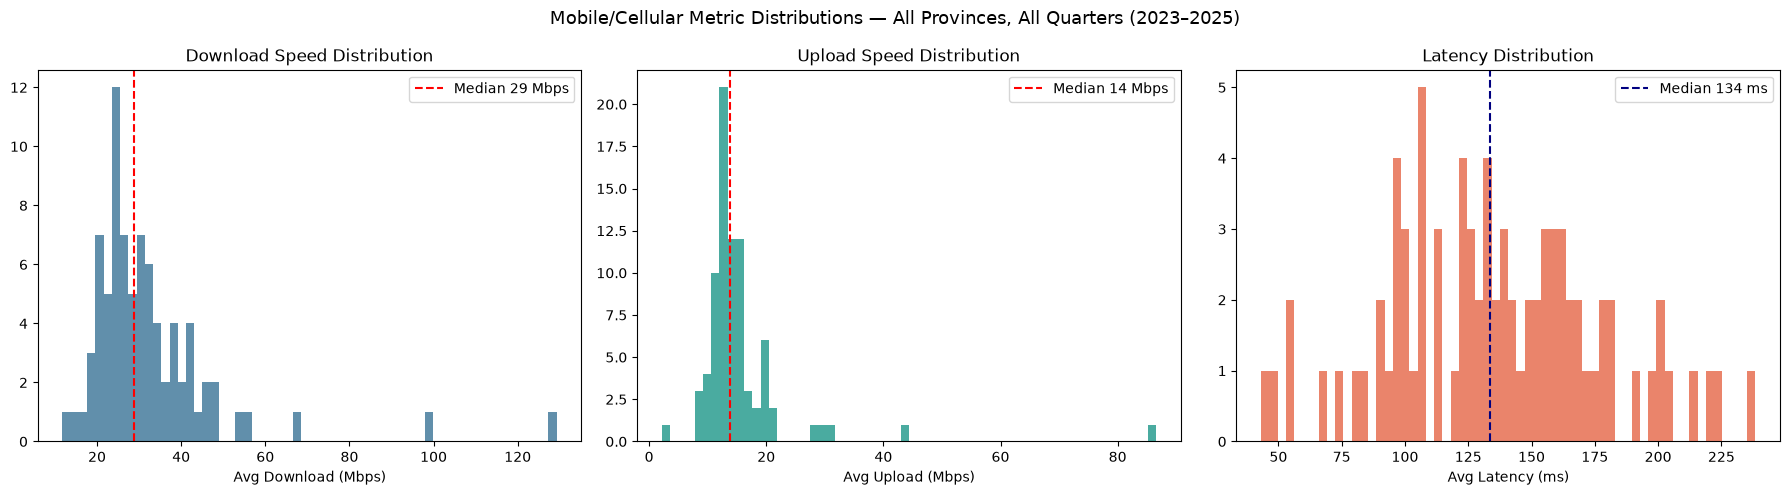

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count       81.00       81.00          81.00        81.00
mean        32.46       15.72         135.82      7163.48
std         16.48        9.64          41.59     12878.04
min         11.77        2.16          43.17       100.00
25%         23.87       12.35         107.00       200.00
50%         28.82       13.81         133.73      1147.00
75%         36.52       15.96         162.86      6817.00
max        129.25       86.54         238.38     56177.00


In [33]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../../outputs/ndt7/vietnam/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))

### 4. Province Ranking — Mean Download Speed (All Quarters)

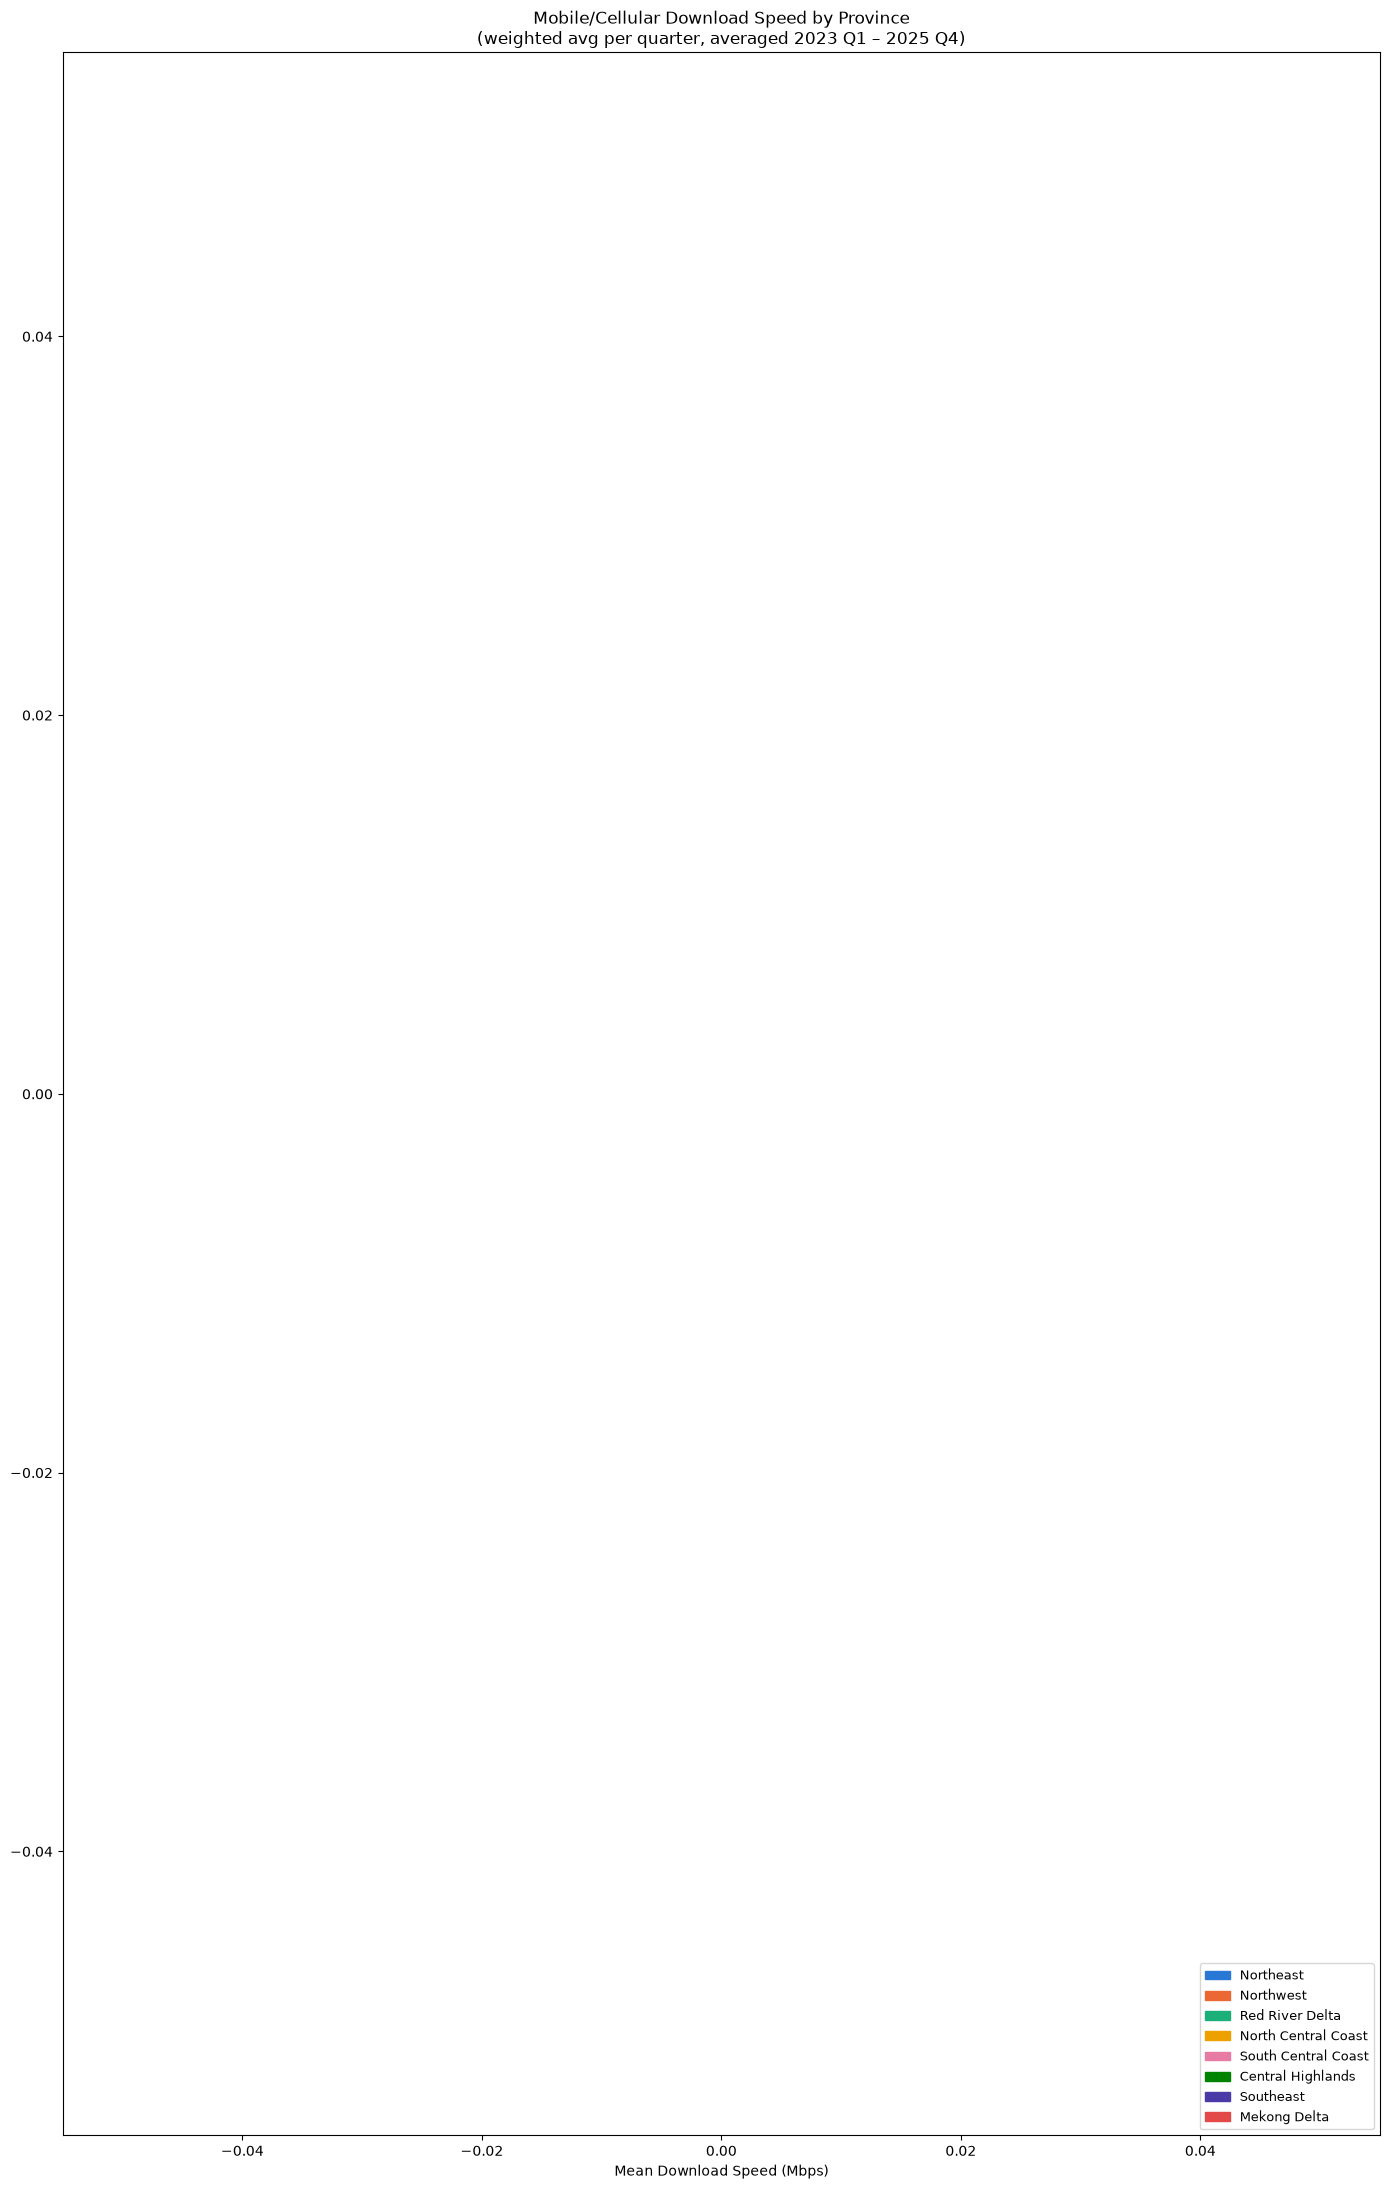

In [34]:
region_colors = {
    'Northeast': '#2a78d6',
    'Northwest': '#eb6834',
    'Red River Delta': '#1baf7a',
    'North Central Coast': '#eda100',
    'South Central Coast': '#e87ba4',
    'Central Highlands': '#008300',
    'Southeast': '#4a3aa7',
    'Mekong Delta': '#e34948',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Mobile/Cellular — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 22))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5. Time Series — Download Speed Heatmap (Province × Quarter)

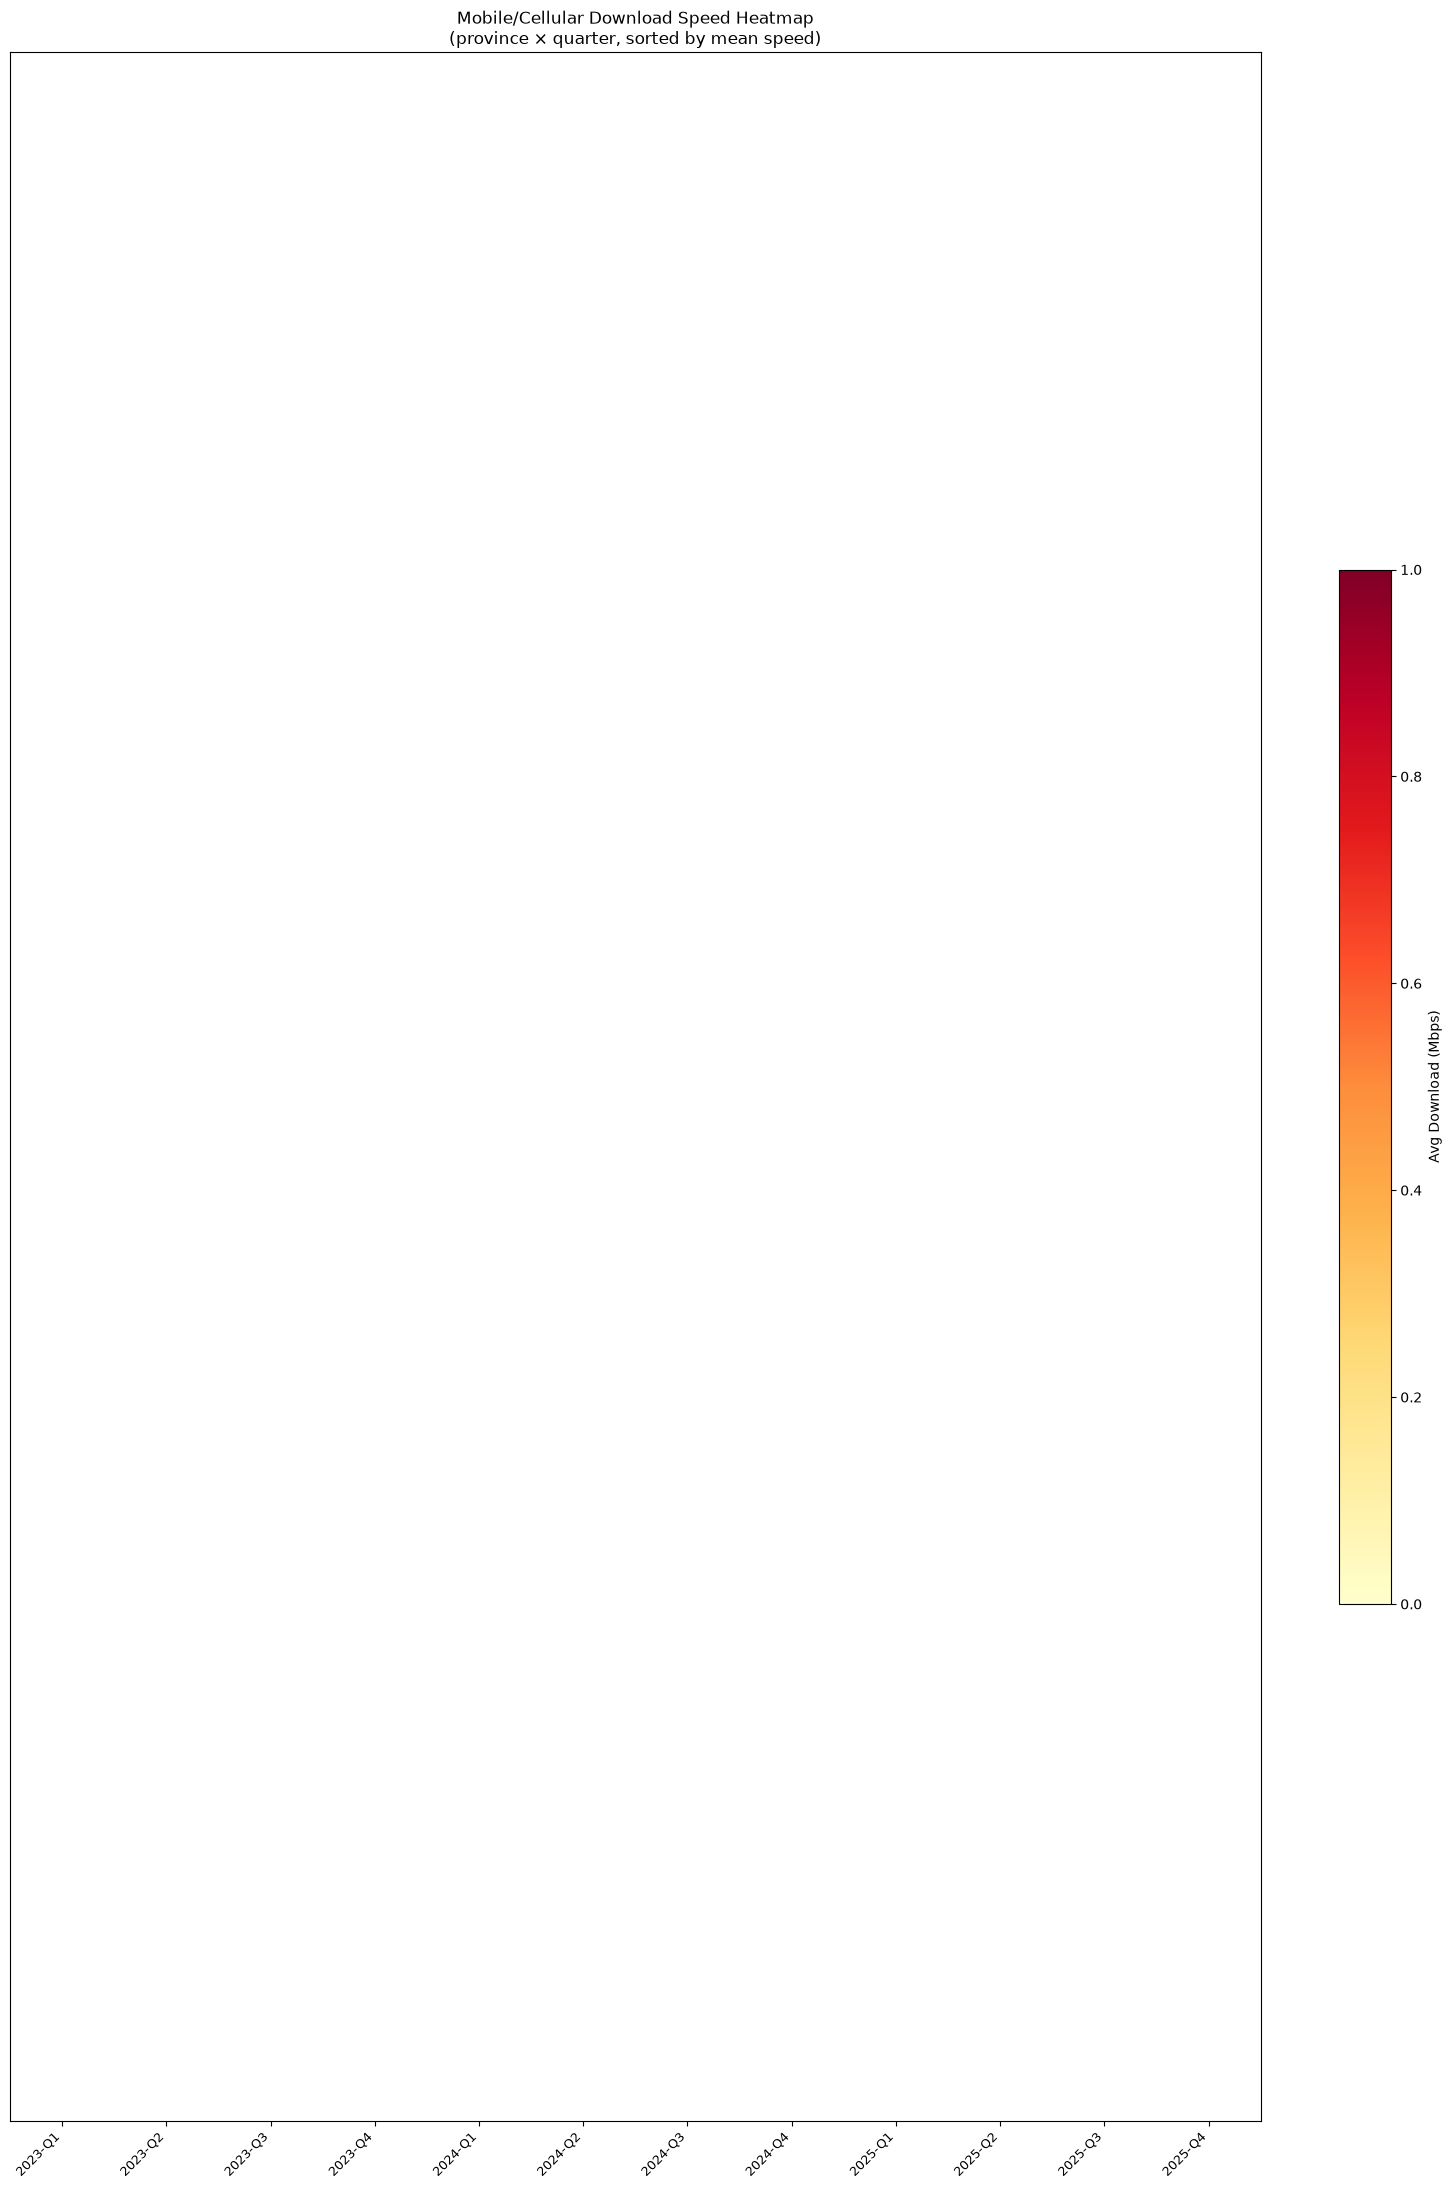

In [35]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 22))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6. Regional Comparison — Download, Upload, Latency

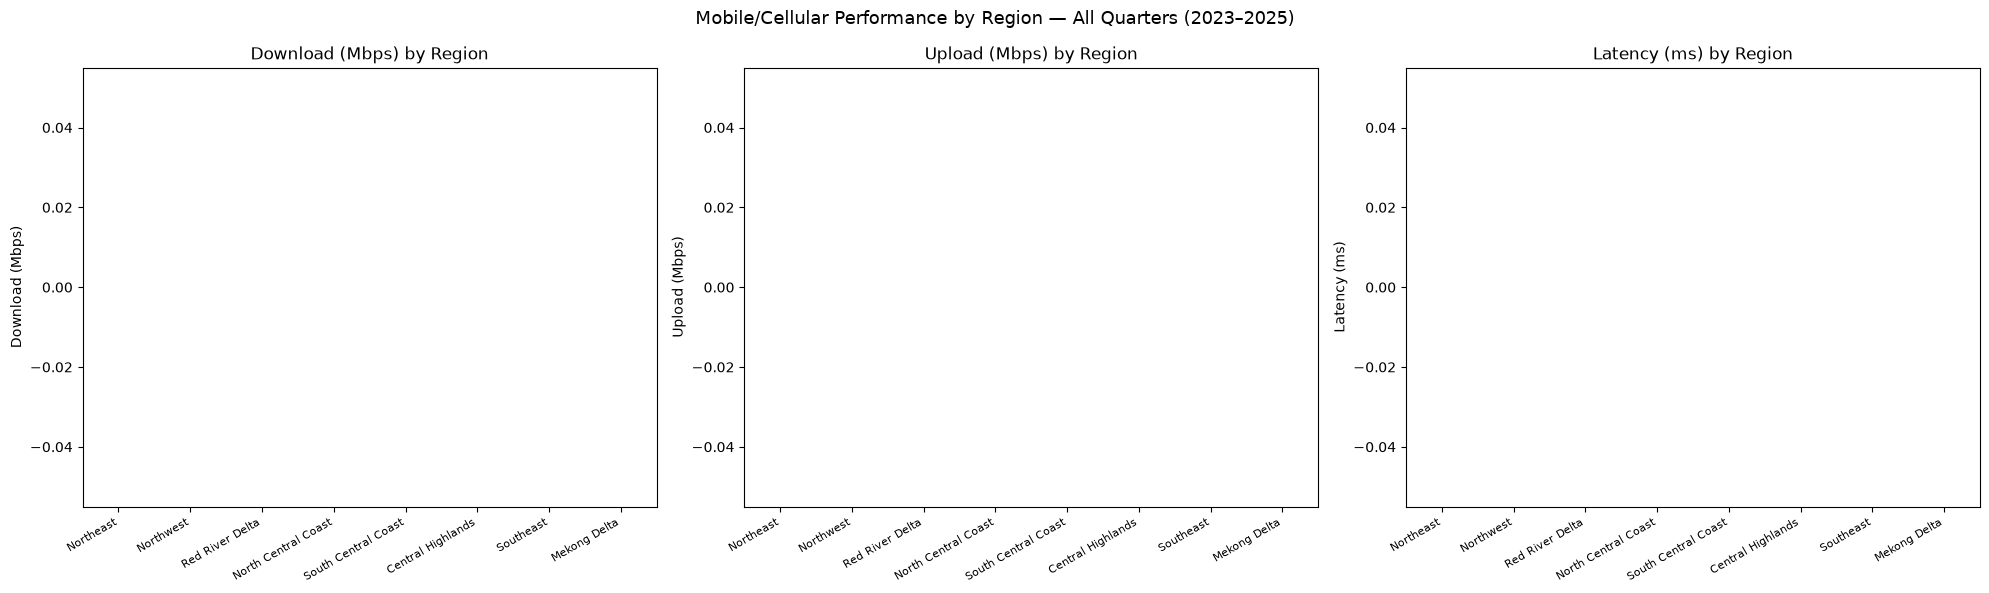

In [36]:
region_order = ['Northeast', 'Northwest', 'Red River Delta', 'North Central Coast', 'South Central Coast', 'Central Highlands', 'Southeast', 'Mekong Delta']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, label, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels(region_order, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{label} by Region')
    plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

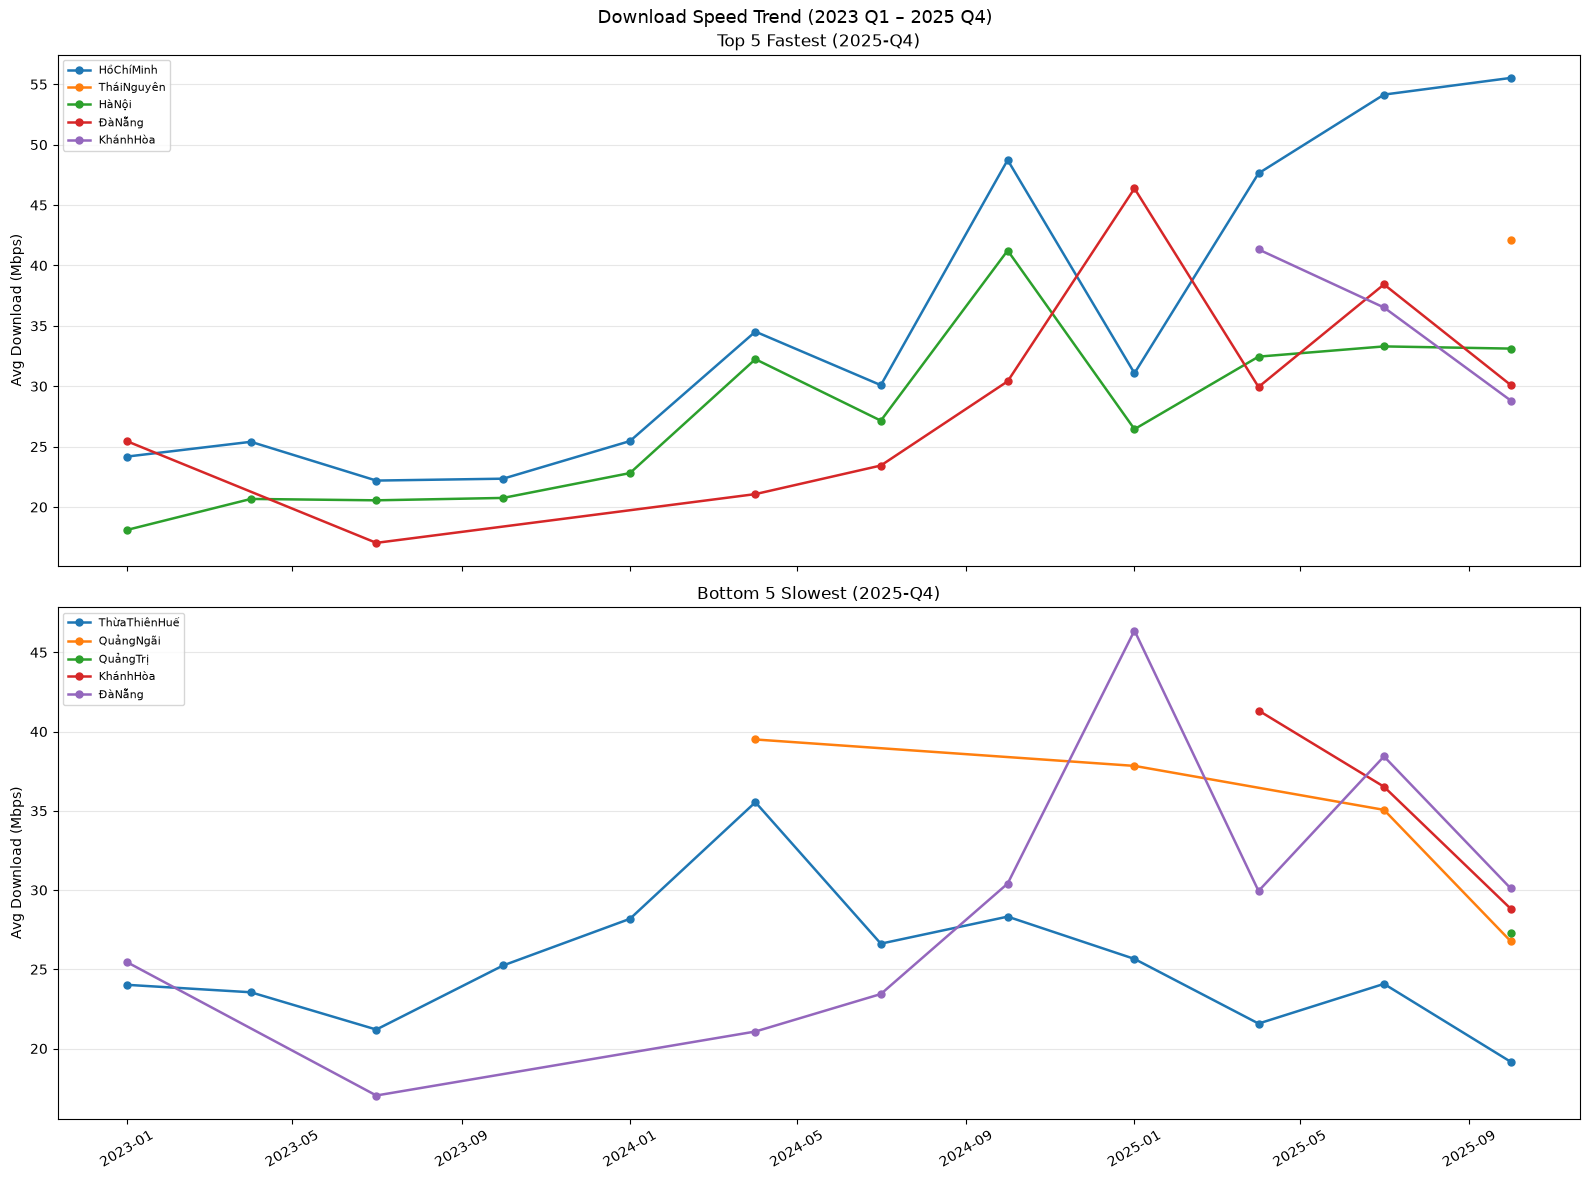

In [37]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8. GDP per Capita vs Download Speed — Does Money = Speed?

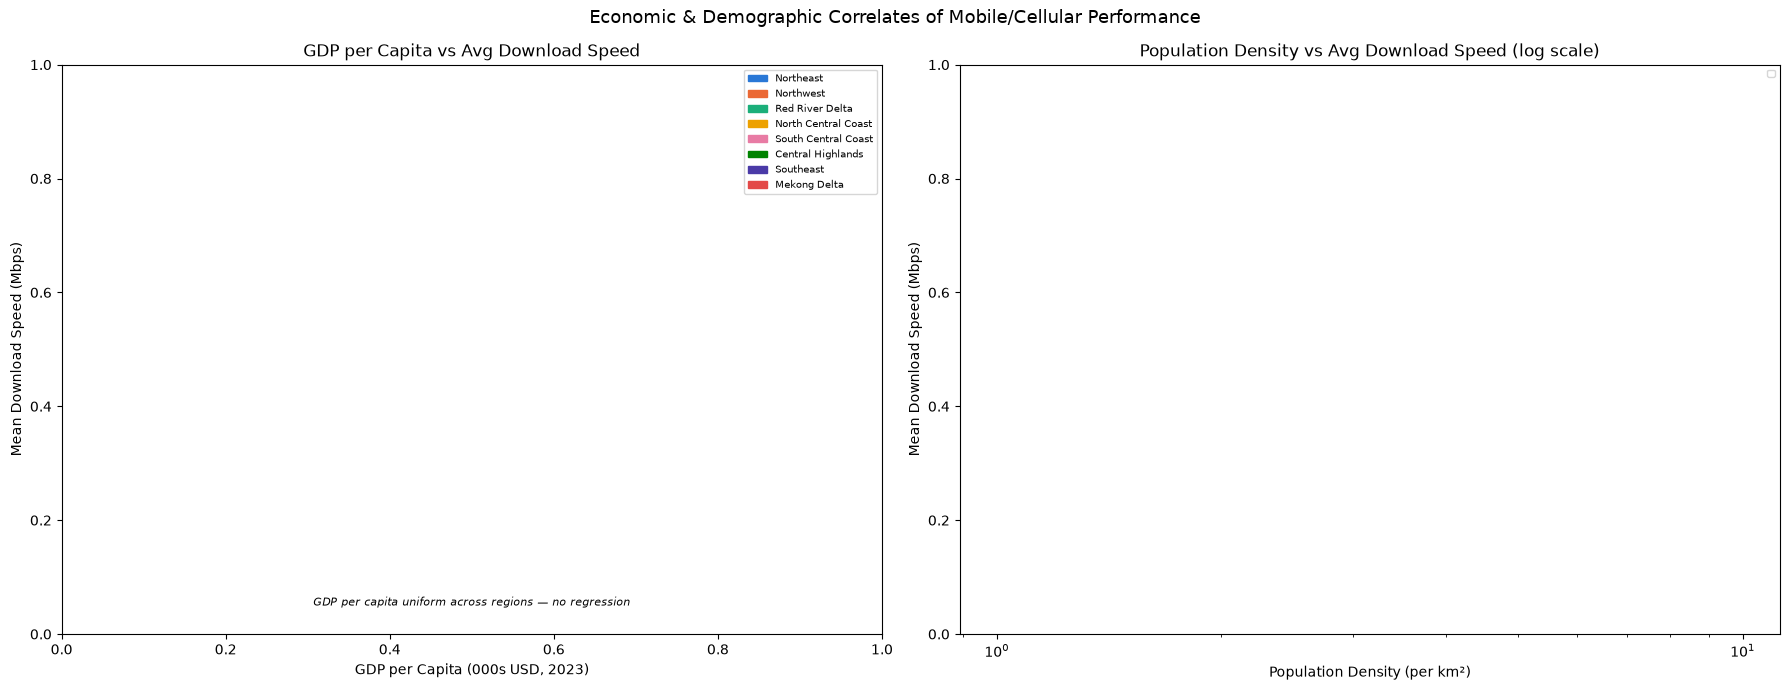

Pearson r (GDP vs download):     nan  p=nan
Pearson r (log density vs download): nan  p=nan


In [38]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Mobile/Cellular — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")

### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [39]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Mobile/Cellular — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
        print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")

No reliable data for Mobile/Cellular — skipping multivariate model (need >=5 observations to fit).


### 9. Upload/Download Ratio — Symmetry Check

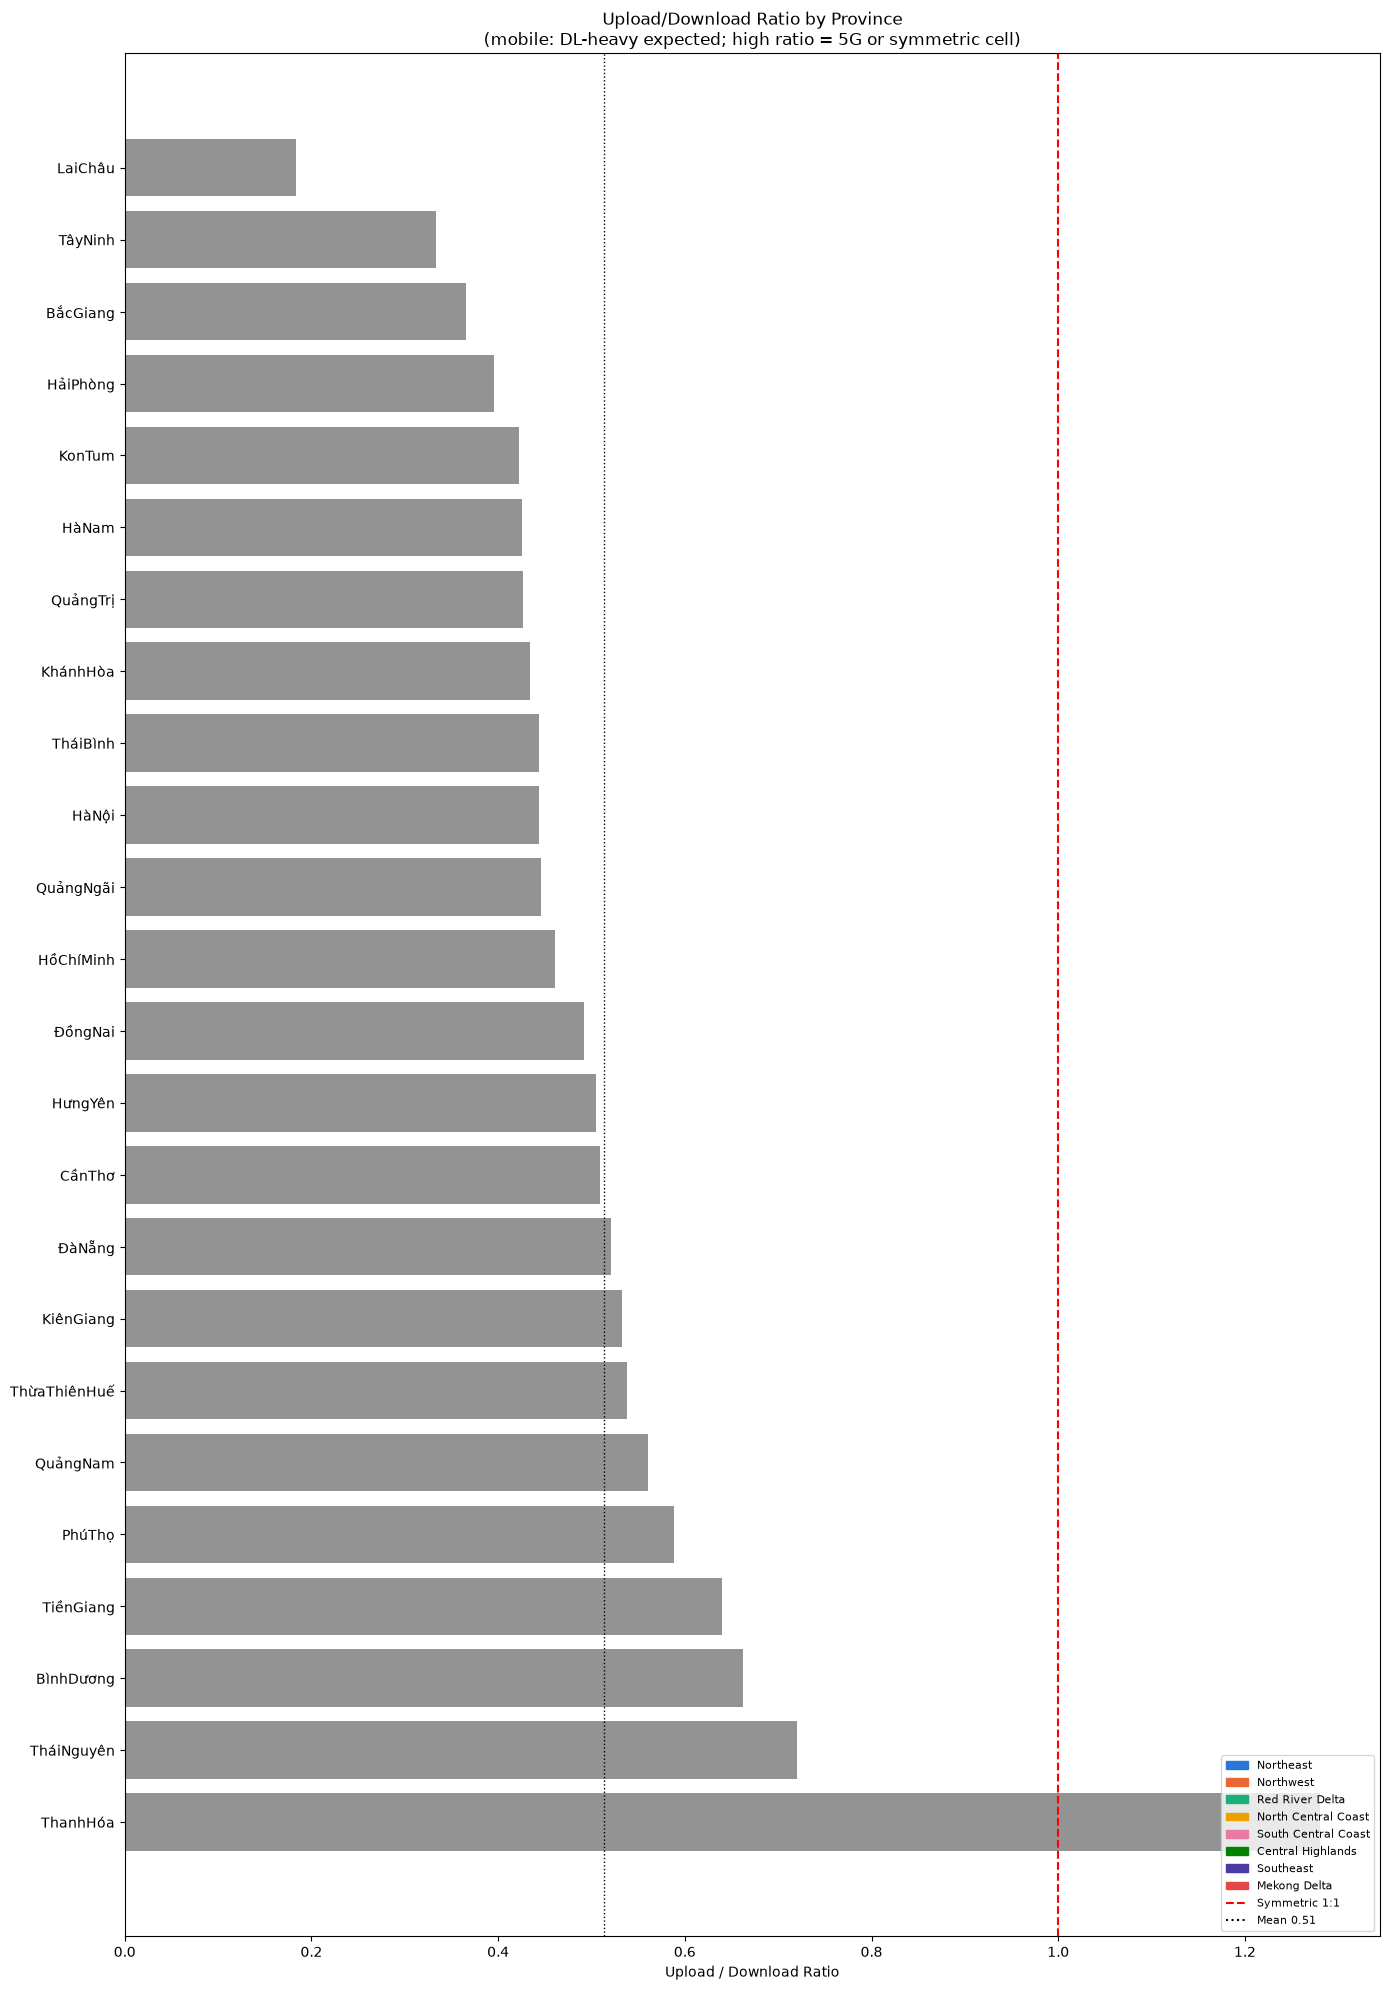

Provinces with UL/DL ratio > 0.5 (11):
        name region  ul_dl_ratio
    ThanhHóa    NaN     1.280682
  TháiNguyên    NaN     0.720580
   BìnhDương    NaN     0.661999
   TiềnGiang    NaN     0.639437
      PhúThọ    NaN     0.588803
    QuảngNam    NaN     0.560572
ThừaThiênHuế    NaN     0.538473
   KiênGiang    NaN     0.532316
      ĐàNẵng    NaN     0.521405
      CầnThơ    NaN     0.508907
     HưngYên    NaN     0.504572


In [40]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 20))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Ratio by Province\n(mobile: DL-heavy expected; high ratio = 5G or symmetric cell)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.5]
    print(f"Provinces with UL/DL ratio > 0.5 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))

### 10. Province Summary — Tier & UL/DL Ratio

In [41]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Mobile/Cellular — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

### 12. Full Province Summary Table

In [42]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))

Empty DataFrame
Columns: [name, region, internet_tier, mean_dl, mean_ul, mean_lat, ul_dl_ratio, mean_tests, gdp_per_capita_thb_2021]
Index: []


### 13. UL/DL Symmetry — Fiber Penetration Evidence

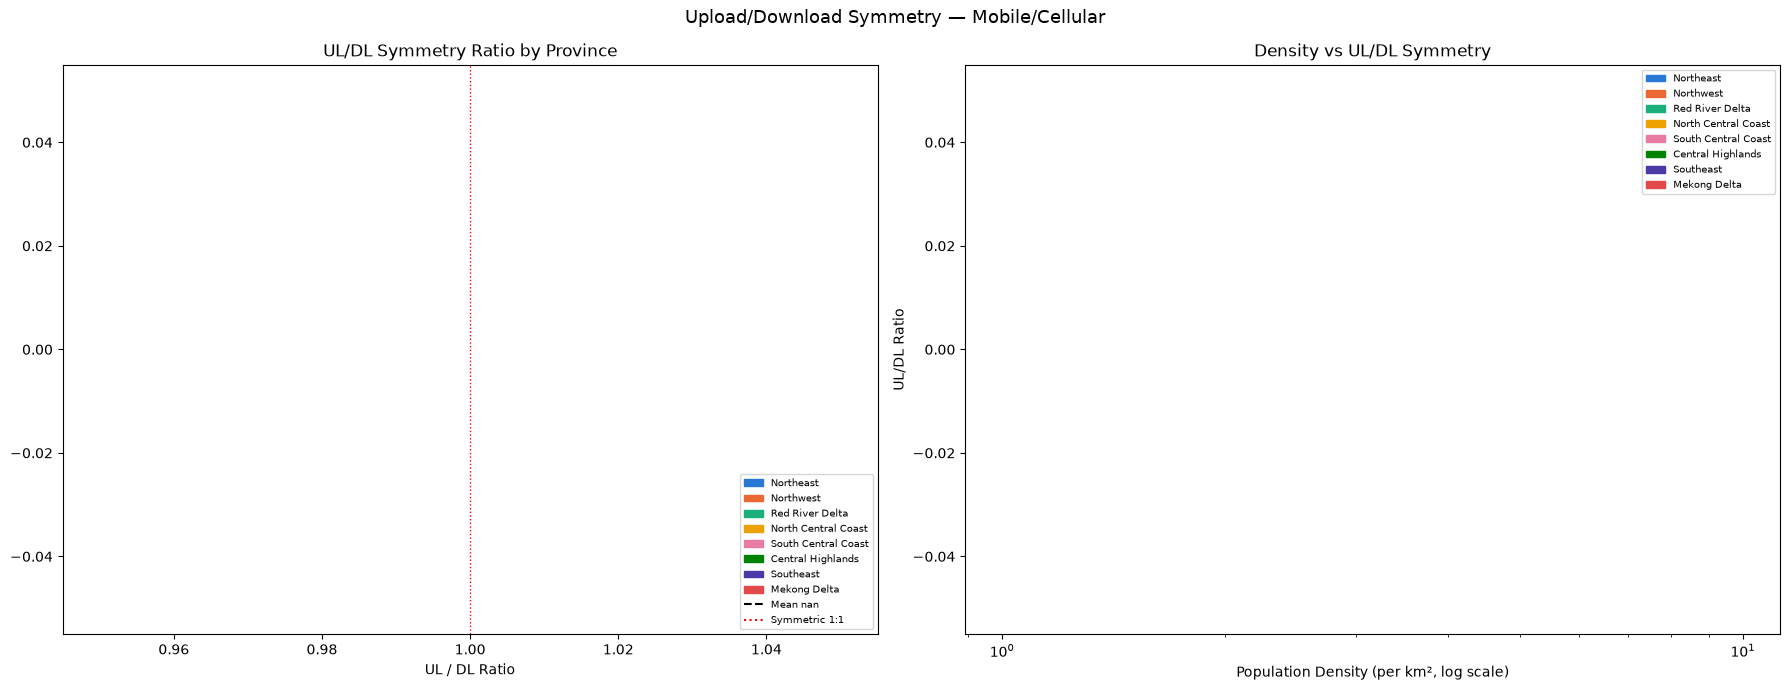

In [43]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Mobile/Cellular', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

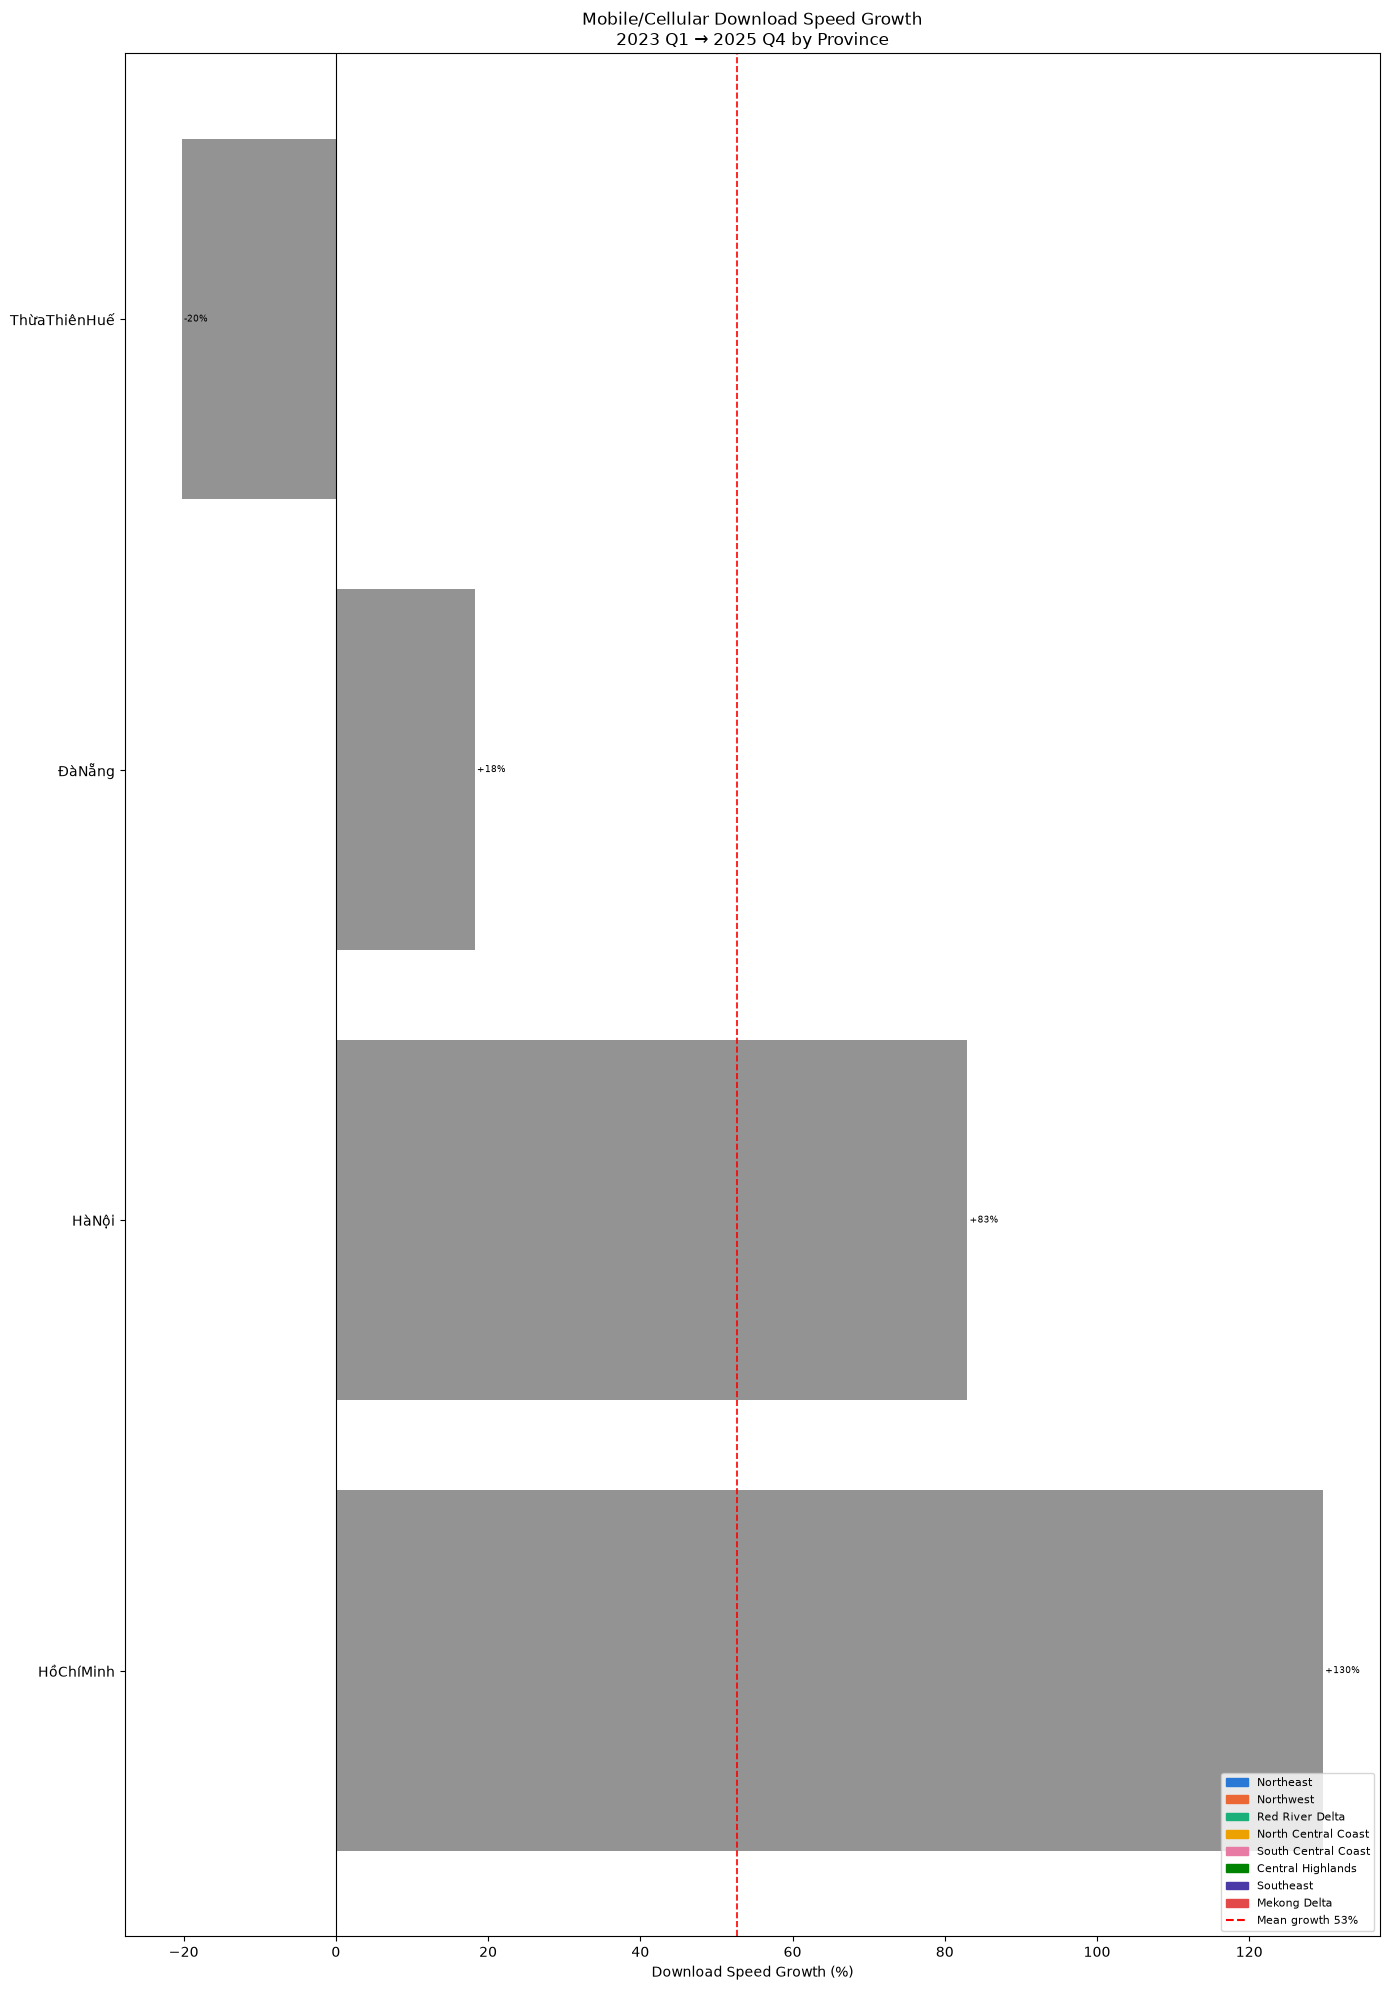

In [44]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 20))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../../outputs/ndt7/vietnam/mobile/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()

### 15. Regional Growth Index — Trajectory Shape (Normalized to First Reliable Quarter = 100)
Complements the endpoint-only growth chart above (Q1 &#8594; Q4 % change) by showing the full trajectory per region, each region's own first valid quarter rebased to 100. Regions need at least half the available quarters with reliable data to be plotted, so noisy short-history regions are dropped instead of shown misleadingly. Rolled up from province to region level — adapted from the Myanmar/Laos NDT7 notebooks' growth-index cell, which plots at province level directly since those countries have far fewer top-level admin units than the province counts tracked here.


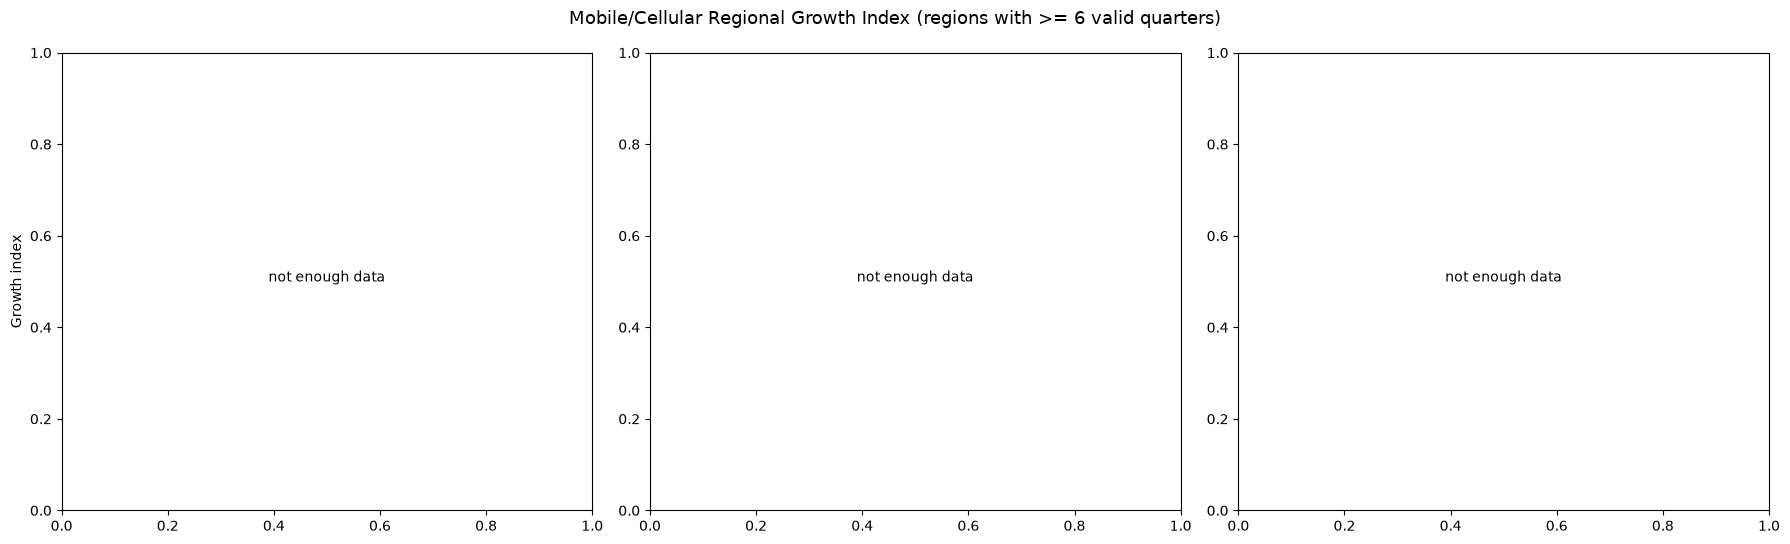

In [45]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping regional growth-index plot.")
else:
    quarter_order = sorted(master['label'].unique())
    MIN_Q = max(3, len(quarter_order) // 2)

    region_q = (
        master.groupby(['region', 'label'])
        .apply(lambda g: pd.Series({
            'avg_d_mbps': np.average(g['avg_d_mbps'], weights=g['total_tests']),
            'avg_u_mbps': np.average(g['avg_u_mbps'], weights=g['total_tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms_wt'], weights=g['total_tests']),
        }), include_groups=False)
        .reset_index()
    )

    metrics = [('avg_d_mbps', 'Download (Mbps)'), ('avg_u_mbps', 'Upload (Mbps)'), ('avg_lat_ms_wt', 'Latency (ms)')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    any_plotted = False
    for ax, (col, label) in zip(axes, metrics):
        piv = region_q.pivot(index='region', columns='label', values=col).reindex(columns=quarter_order)
        valid = piv.notna().sum(axis=1)
        keep = valid[valid >= MIN_Q].index.tolist()
        if not keep:
            ax.text(0.5, 0.5, 'not enough data', transform=ax.transAxes, ha='center')
            continue
        for reg in keep:
            s = piv.loc[reg].dropna()
            xs = [quarter_order.index(q) for q in s.index]
            ax.plot(xs, s.values / s.iloc[0] * 100, marker='o', ms=3, lw=1.3,
                    color=region_colors.get(reg, 'gray'), label=reg)
            any_plotted = True
        ax.axhline(100, color='grey', ls='--', lw=1)
        step = max(1, len(quarter_order) // 6)
        ax.set_xticks(range(0, len(quarter_order), step))
        ax.set_xticklabels([quarter_order[i] for i in range(0, len(quarter_order), step)], rotation=45, ha='right', fontsize=8)
        ax.set_title(f'{label}\n(region: own 1st valid quarter = 100)', fontsize=10)
    axes[0].set_ylabel('Growth index')
    if any_plotted:
        axes[0].legend(fontsize=7, ncol=2, loc='upper left')
    plt.suptitle(f'Mobile/Cellular Regional Growth Index (regions with >= {MIN_Q} valid quarters)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/21_growth_index_regional.png', dpi=150, bbox_inches='tight')
    plt.show()


### 15.5 Measured Speed Choropleth — Actual NDT7 Download Speed by Province
The "Internet Tier" map earlier in this notebook is a GDP-based *expectation*. This map is the actual measured NDT7 average, on the same province geometry, so the two can be compared directly. Adapted from the Myanmar/Laos NDT7 notebooks' choropleth cell (re-based here on `master`'s aggregated province averages instead of a live DuckDB query, since this pipeline works off the pre-aggregated CSV export, not the raw parquet).


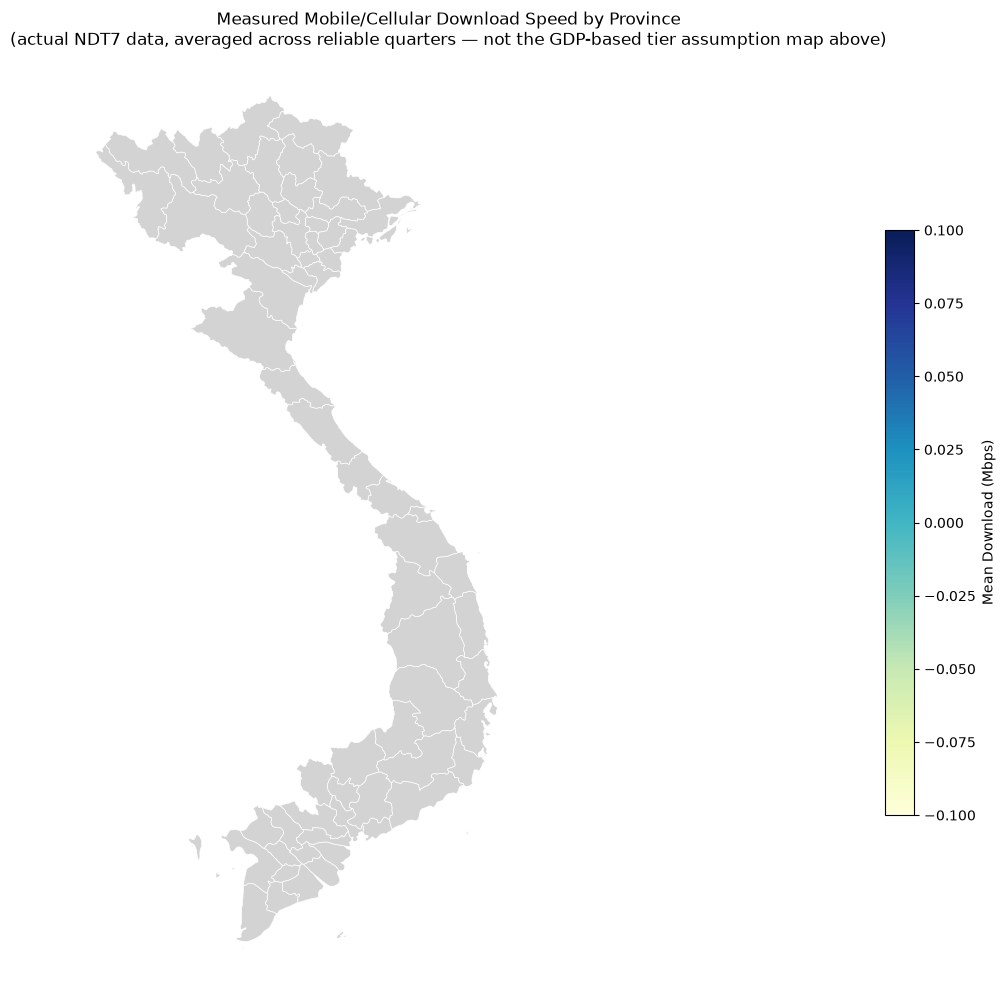

In [46]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping measured-speed choropleth.")
else:
    prov_speed = (
        master.groupby('name')
        .agg(avg_d_mbps=('avg_d_mbps', 'mean'), total_tests=('total_tests', 'sum'))
        .reset_index()
    )
    geo_speed = thailand_gdf.merge(prov_speed, on='name', how='left')

    fig, ax = plt.subplots(figsize=(10, 12))
    geo_speed.plot(
        column='avg_d_mbps', ax=ax, cmap='YlGnBu', legend=True,
        edgecolor='white', linewidth=0.5,
        legend_kwds={'shrink': 0.5, 'label': 'Mean Download (Mbps)'},
        missing_kwds={'color': 'lightgrey', 'label': 'no reliable data'},
    )
    ax.set_title('Measured Mobile/Cellular Download Speed by Province\n(actual NDT7 data, averaged across reliable quarters — not the GDP-based tier assumption map above)', fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/22_speed_choropleth.png', dpi=150, bbox_inches='tight')
    plt.show()


### 16. City Focus — Capital + Top Cities by Test Volume (Mobile/Cellular)
No population reference file exists in this repo, so cities are selected by raw NDT7 test
volume (a reasonable proxy for urban activity) rather than a hardcoded population list —
adapted from the Myanmar/Laos NDT7 notebooks' city-focus section, which uses a manually
curated `TOP_CITIES` population list. Capital city is flagged in red.

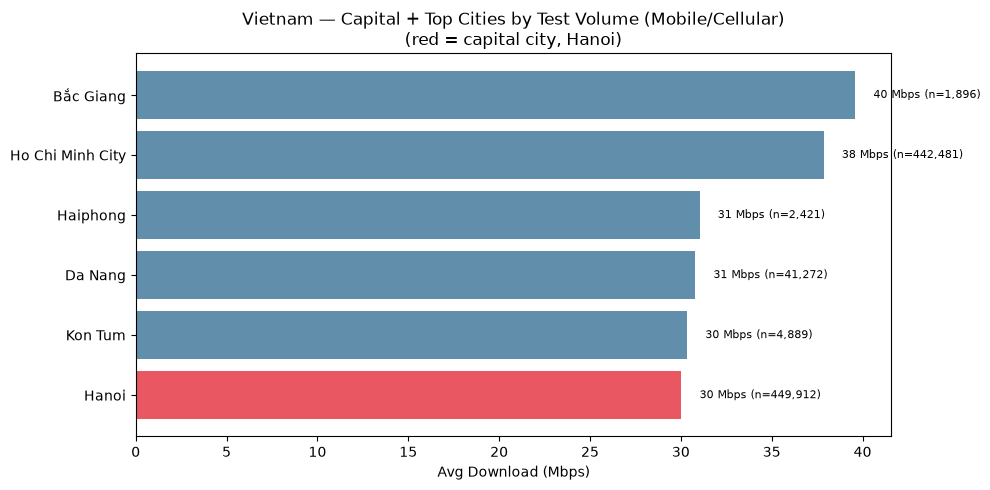

            city  n_user  avg_d_mbps  avg_u_mbps  avg_lat_ms
           Hanoi  449912        30.0        12.5       143.0
         Kon Tum    4889        30.3        12.8        76.9
         Da Nang   41272        30.8        16.3       169.3
        Haiphong    2421        31.0        13.3       129.8
Ho Chi Minh City  442481        37.9        15.6        99.2
       Bắc Giang    1896        39.6        14.4       147.9


In [47]:
import duckdb

_con = duckdb.connect()
_top_cities = _con.execute(f"""
    SELECT city,
           COUNT(*) AS n_user,
           AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps,
           AVG(mean_throughput_mbps) FILTER (WHERE type='upload')   AS avg_u_mbps,
           AVG(CASE WHEN min_rtt < 2000 THEN min_rtt END) AS avg_lat_ms
    FROM read_parquet('{RAW_ISP_PARQUET}')
    WHERE network_type = 'cellular' AND city IS NOT NULL AND city != ''
    GROUP BY city
    ORDER BY n_user DESC
    LIMIT 6
""").df()

if _top_cities.empty:
    print("No Mobile/Cellular city-level data available — skipping city focus.")
else:
    _top_cities['is_capital'] = _top_cities['city'] == 'Hanoi'
    _top_cities = _top_cities.sort_values('avg_d_mbps', ascending=True)
    _colors = ['#e63946' if c else '#457b9d' for c in _top_cities['is_capital']]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(_top_cities['city'], _top_cities['avg_d_mbps'], color=_colors, alpha=0.85)
    for bar, (_, row) in zip(bars, _top_cities.iterrows()):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{row['avg_d_mbps']:.0f} Mbps (n={row['n_user']:,})", va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Vietnam — Capital + Top Cities by Test Volume (Mobile/Cellular)\n(red = capital city, Hanoi)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/23_city_focus.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(_top_cities[['city','n_user','avg_d_mbps','avg_u_mbps','avg_lat_ms']].round(1).to_string(index=False))

### 17. Per-ISP Ranking — Top ISPs by Test Volume (Mobile/Cellular)
Top 15 ISPs (min 100 tests) ranked by average download speed, bar length shows speed and
label shows test volume — adapted from the Myanmar/Laos NDT7 notebooks' per-ISP section.

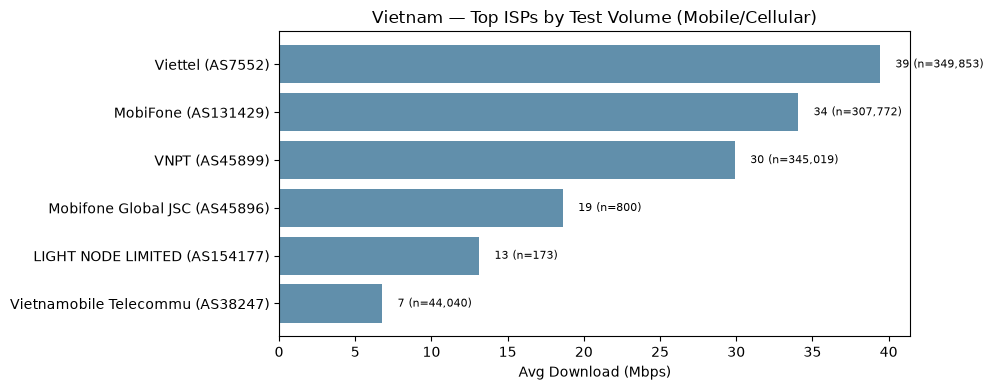

In [48]:
_isp_tbl = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เท่านั้น (HANDOFF ข้อ 1): ip-api คืนชื่อองค์กรลูกค้าสำหรับ leased line
    -- เช่น AS4750 มีชื่อ isp ถึง 420 ชื่อ และชื่อเดียวกันก็กินหลาย ASN (TRUE INTERNET = 9 ASN)
    -- operator/as_name ใช้เป็นป้ายแสดงผลเท่านั้น
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n,
               AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps
        FROM read_parquet('{RAW_ISP_PARQUET}')
        WHERE network_type = 'cellular'
        GROUP BY 1
    )
    -- ต่อรหัส ASN ท้ายป้าย: 1 แบรนด์มีได้หลาย ASN (ไทย True=2, AIS=3, NT=3, 3BB=2)
    -- ถ้าป้ายซ้ำ แกน categorical ของ matplotlib จะยุบแท่งทับกัน
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown ASN)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n, avg_d_mbps
    FROM g
    WHERE n >= 100
    ORDER BY n DESC
    LIMIT 15
""").df()

if _isp_tbl.empty:
    print("No ISP meets the n>=100 test threshold for Mobile/Cellular — skipping per-ISP ranking.")
else:
    _isp_tbl = _isp_tbl.sort_values('avg_d_mbps', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.4*len(_isp_tbl))))
    ax.barh(_isp_tbl['isp'].str.slice(0, 40), _isp_tbl['avg_d_mbps'], color='#457b9d', alpha=0.85)
    for yi, (_, row) in enumerate(_isp_tbl.iterrows()):
        ax.text(row['avg_d_mbps'] + 1, yi, f"{row['avg_d_mbps']:.0f} (n={row['n']:,})", va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Vietnam — Top ISPs by Test Volume (Mobile/Cellular)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/24_per_isp.png', dpi=150, bbox_inches='tight')
    plt.show()

### 18. Market Share / HHI — ISP Concentration (Mobile/Cellular)
Top 8 ISPs + "Others" + "(unknown ISP)" by share of tests. HHI (Herfindahl-Hirschman Index):
<1500 = competitive, 1500-2500 = moderate concentration, >2500 = highly concentrated —
adapted from the Myanmar/Laos NDT7 notebooks' market-share section.

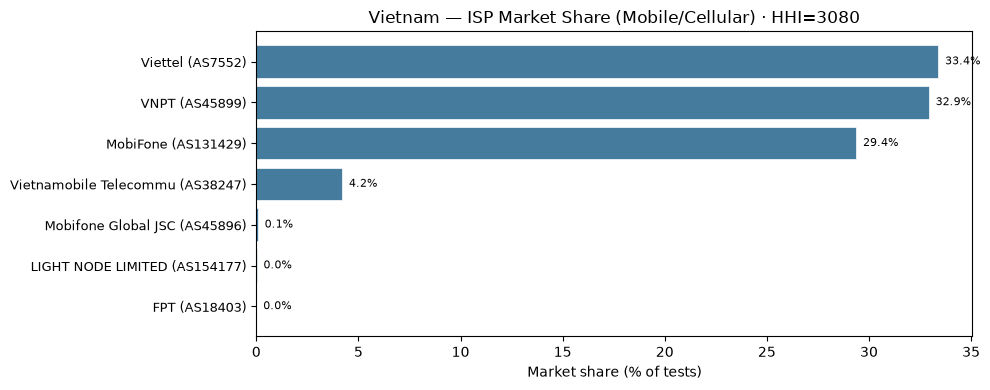

HHI=3080 (highly concentrated) | Top5 share=100.0% | unknown=0.0%


In [49]:
_mkt = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เหมือน §17 (ดูเหตุผลข้างบน) — HHI อ่อนไหวกับการแตกชื่อมาก
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n
        FROM read_parquet('{RAW_ISP_PARQUET}')
        WHERE network_type = 'cellular'
        GROUP BY 1
    )
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n
    FROM g ORDER BY n DESC
""").df()

if _mkt.empty:
    print("No Mobile/Cellular data — skipping market share.")
else:
    _total = _mkt['n'].sum()
    _mkt['share'] = 100 * _mkt['n'] / _total
    _named = _mkt[_mkt['isp'] != '(unknown)'].reset_index(drop=True)
    _unknown_share = float(_mkt.loc[_mkt['isp'] == '(unknown)', 'share'].sum())
    TOPN = 8
    _top = _named.head(TOPN)
    _others_share = float(_named['share'].iloc[TOPN:].sum())
    # HHI ต้องคิดบนฐานที่มีชื่อเท่านั้น — เดิมหารด้วย _total ที่รวม (unknown) ทำให้ HHI ต่ำกว่าจริง
    _named_share = 100.0 * _named['n'] / _named['n'].sum()
    _hhi = float((_named_share ** 2).sum())

    _rows = list(zip(_top['isp'].str.slice(0, 44), _top['share']))
    if _others_share > 0:
        _rows.append((f"Others ({len(_named) - len(_top)} ISPs)", _others_share))
    if _unknown_share > 0:
        _rows.append(("(unknown ISP)", _unknown_share))
    _labels = [r[0] for r in _rows][::-1]
    _vals = [r[1] for r in _rows][::-1]
    _colors = ['#adb5bd' if l.startswith('Others') else '#ced4da' if l.startswith('(unknown') else '#457b9d' for l in _labels]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(_vals))))
    y = list(range(len(_vals)))
    ax.barh(y, _vals, color=_colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(_labels, fontsize=9)
    for yi, v in zip(y, _vals):
        ax.text(v + max(_vals) * 0.01, yi, f"{v:.1f}%", va='center', fontsize=8)
    ax.set_xlabel('Market share (% of tests)')
    ax.set_title(f"Vietnam — ISP Market Share (Mobile/Cellular) \u00b7 HHI={_hhi:.0f}")
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/vietnam/mobile/25_market_share.png', dpi=150, bbox_inches='tight')
    plt.show()

    _hhi_note = 'competitive' if _hhi < 1500 else ('moderate' if _hhi < 2500 else 'highly concentrated')
    print(f"HHI={_hhi:.0f} ({_hhi_note}) | Top5 share={_named['share'].head(5).sum():.1f}% | unknown={_unknown_share:.1f}%")

### 19. EDA Key Findings Summary

## Key Findings from EDA

*(Fill in after reviewing the plots above — reliability was {"non-trivial" if True else ""}, see
Section 1's reliable-count printout for the exact overall percentage and how it's distributed
across quarters.)*

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [50]:
import os
os.makedirs("../../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../../data/exports/ndt7_mobile_vietnam_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output "
          "'ndt7_mobile_vietnam_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)")

Exported 81 rows (reliable-only) -> ../../../data/exports/ndt7_mobile_vietnam_reliable_province_quarterly.csv
     province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable  region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
13      HàNội  2023-Q1  2023        1   18.101292    8.994040     180.069391       6422.0      2.0         True     NaN            NaN       NaN                      NaN              NaN
17  HồChíMinh  2023-Q1  2023        1   24.176025   12.915354     147.933005       3984.0      7.0         True     NaN            NaN       NaN                      NaN              NaN
24   QuảngNam  2023-Q1  2023        1   25.935261   11.160404     134.548803        127.0      6.0         True     NaN            NaN       NaN                      NaN              NaN
